# Demo 4: Reducing data to a single dimension based on distance to a control behavior distribution

Sedona Ewbank (snewbank@stanford.edu), 24-07-29

## Import dependencies

In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import rcParams
import scipy
from scipy import optimize, stats, special
import numpy as np
import importlib
import os
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

#import utils
from utils import analysis, plot, metadata

importlib.reload(analysis)
importlib.reload(plot)
importlib.reload(metadata)

<module 'utils.metadata' from '/Users/snewbank/PycharmProjects/MARIPOSA/utils/metadata.py'>

In [9]:
# import sys
# sys.path.append("/Users/snewbank/PycharmProjects/")
# from MARIPOSA.utils import analysis, metadata, plot

## Exercise 1: Dose-response

In [2]:
importlib.reload(analysis)
importlib.reload(plot)

config_path="/Users/snewbank/Behavior/MARIPOSA_test/240730_vame-all/config_pk.yaml"
save_path="/Users/snewbank/Behavior/MARIPOSA_test/240730_vame-all/demo_pk/"
save=False

#Load config
config = metadata.load_project(config_path)

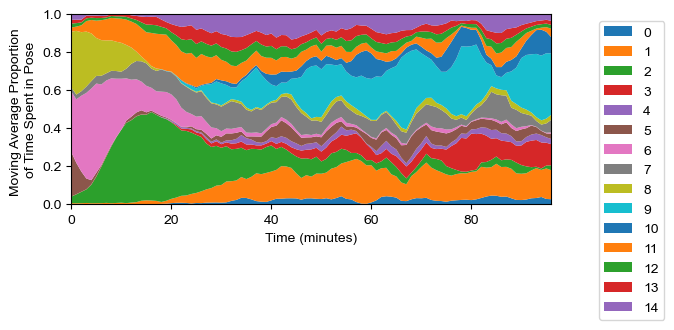

In [3]:
group="k10iv"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 30, 100)

In [4]:
labels_df, n_modules = analysis.label_counter_subgroups(config,0,3600,selected_subgroups=["k10iv"])
#fig = plot.plot_module_usage_subgroups(config, labels_df, 0, 3600)

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

def module_usage_density(config,
                         labels_df,
                         start,
                         time_per_block,
                         n_blocks,
                         posenames=None,
                         convolve=4):
    """
    Plots usage of pose modules over time within a session
    :param labels_df:
    :param start: time to start at in seconds
    :param time_per_block: time per block in seconds
    :param fps: frames per second
    :param n_blocks:
    :param figW:
    :param figH:
    :param posenames:
    :param title:
    :param convolve:
    :param legend:
    :param plottype:
    :param saveplots:
    :param savename:
    :return:
    """
    fps = config["fps"]
    n_samples = len(labels_df.columns)
    labels_flat = np.array(labels_df)
    labels_flat = [item for sublist in labels_flat for item in sublist]
    clusts = np.unique(labels_flat)
    n_clust = len(clusts)
    block_labels = np.zeros([n_samples, n_clust, n_blocks])
    block_labels_normal = np.zeros([n_samples, n_clust, n_blocks])
    block_labels_normal_conv = np.zeros([n_samples, n_clust, n_blocks-(convolve-1)])
    frames_per_block = int(fps * time_per_block)
    for i in range(n_samples):
        for b in range(n_blocks):
            new_start = start + b * frames_per_block
            x = labels_df[labels_df.columns[i]][new_start:new_start + frames_per_block]
            for q in range(n_clust):
                block_labels[i, q, b] = np.count_nonzero(x == q)
                block_labels_normal[i, q, b] = np.count_nonzero(x == q) / frames_per_block
        for q in range(n_clust):
            #print(block_labels_normal[i, q, :])
            block_labels_normal_conv[i, q, :] = moving_average(block_labels_normal[i, q, :],convolve)
        

    return block_labels_normal, block_labels_normal_conv

block_labels_normal_unconv, block_labels_normal = module_usage_density(config, labels_df["k10iv"],0, 30, 100)
block_labels_normal.shape

(7, 15, 97)

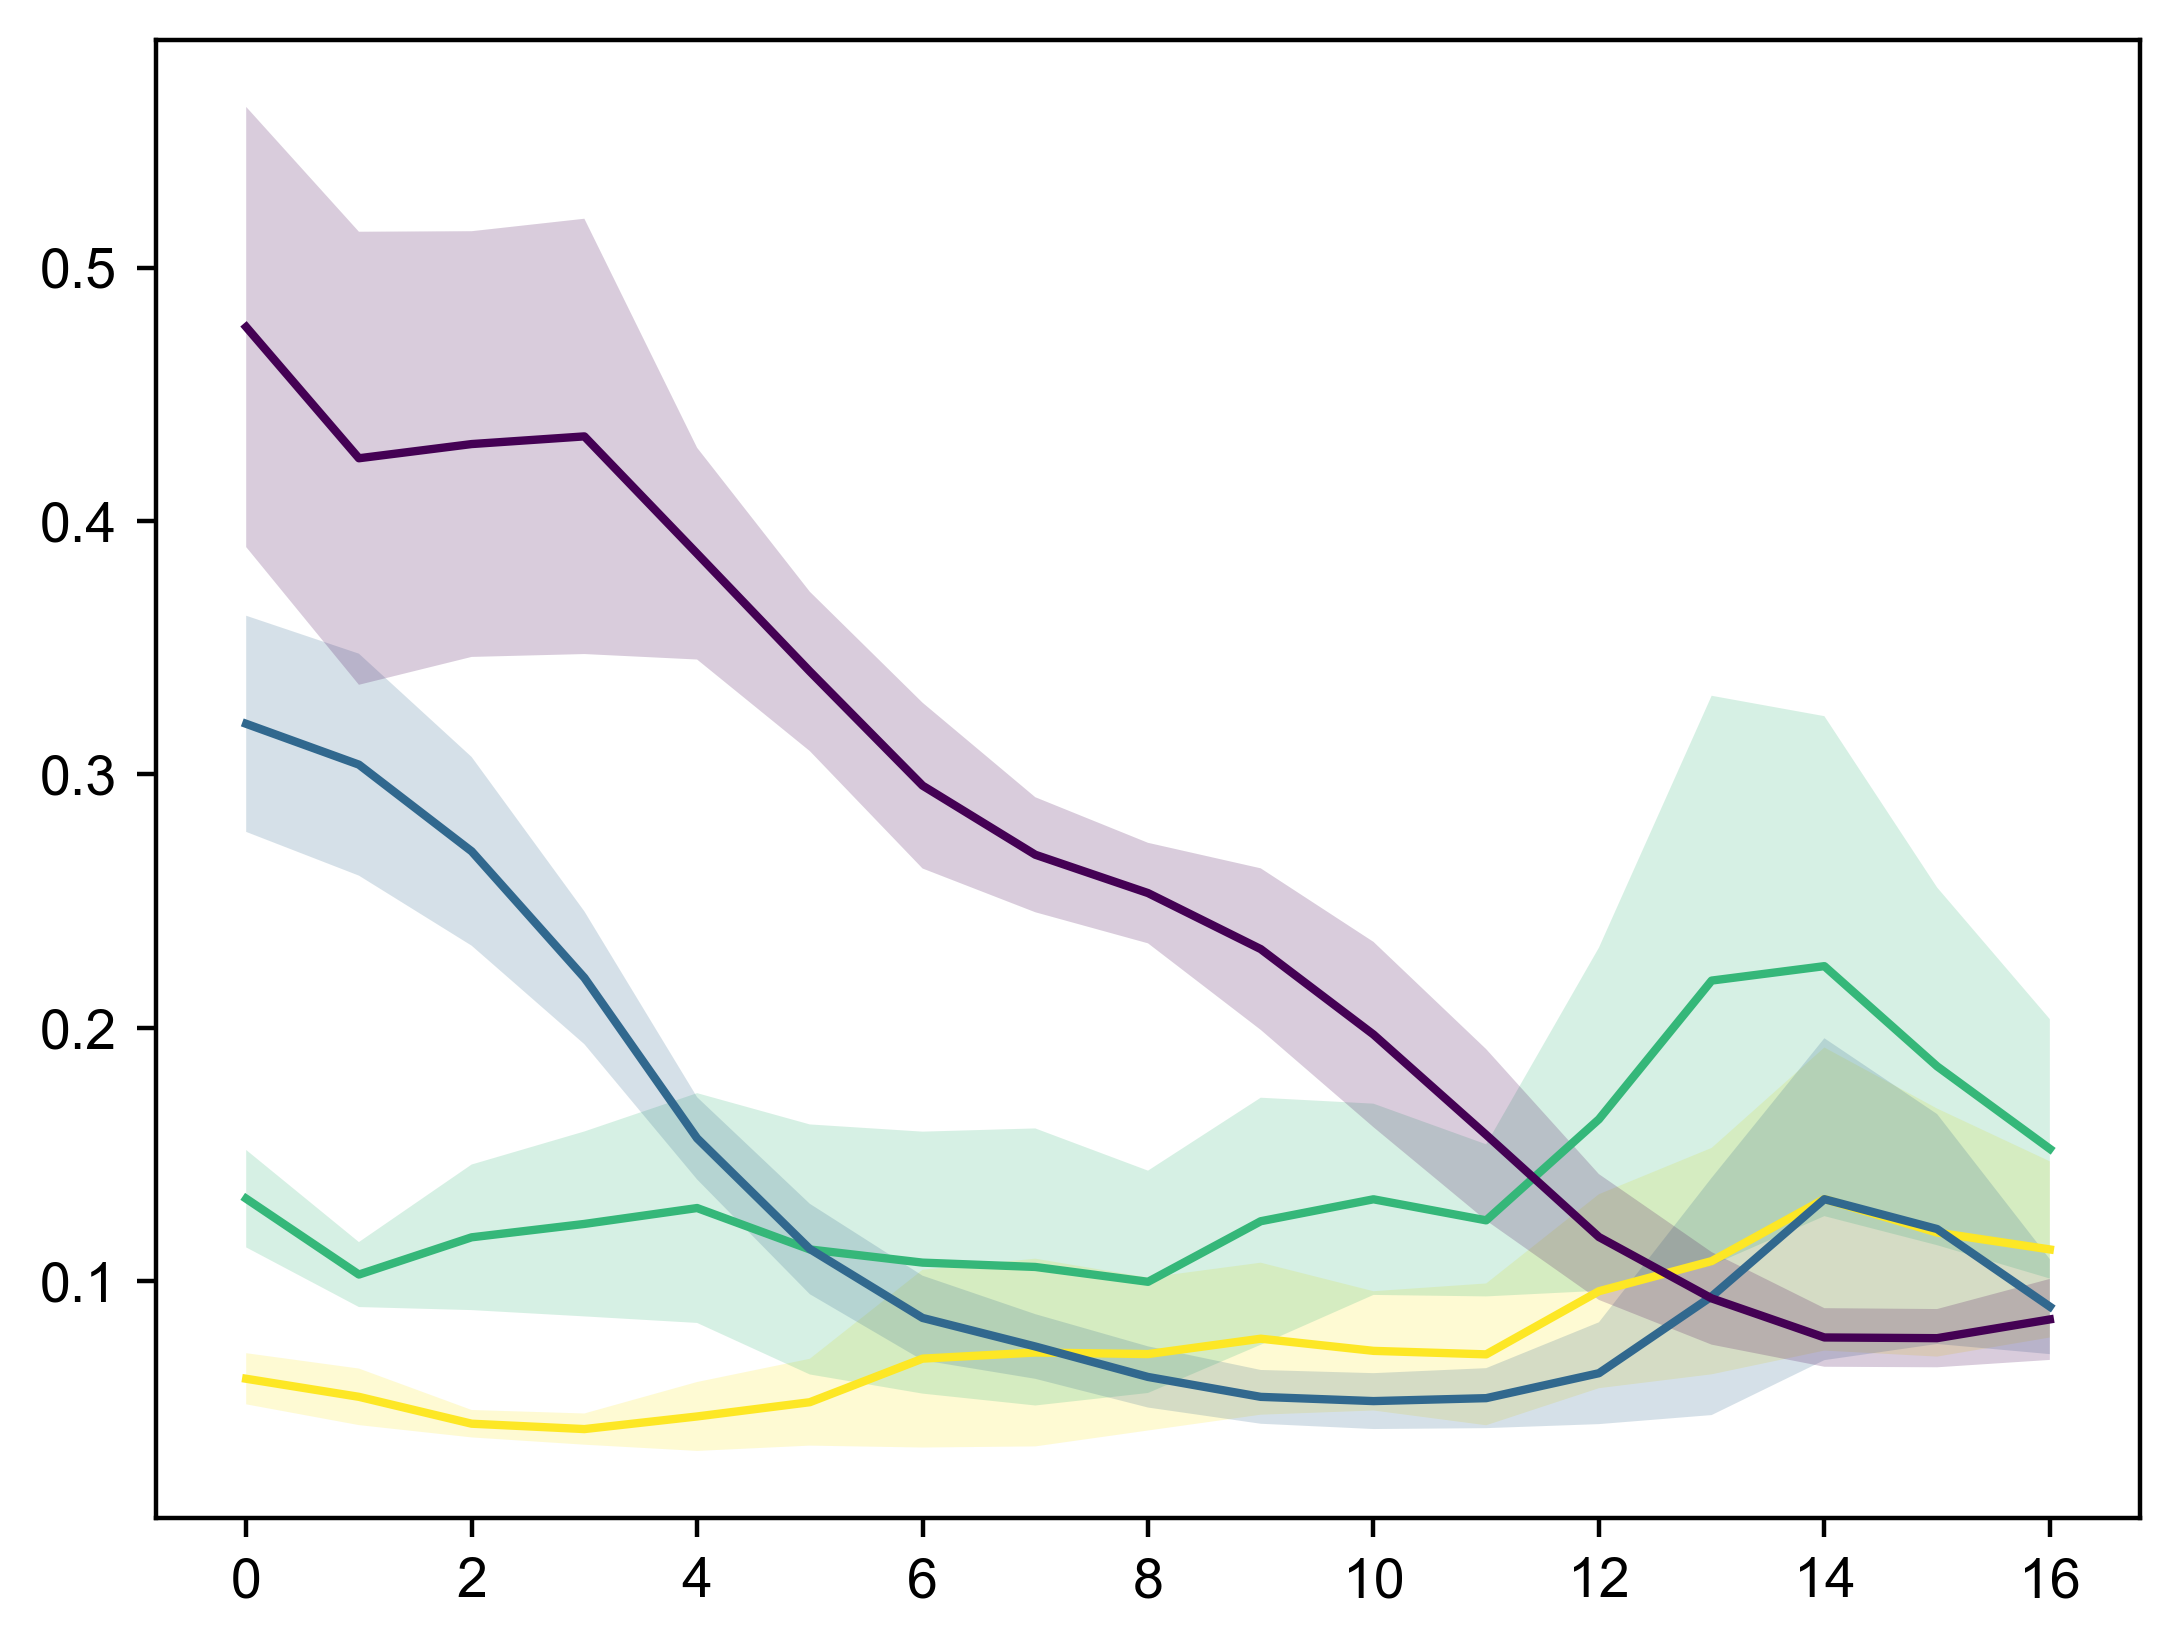

In [5]:
def module_usage_dist(config,labels_df):
    """
    Gives frequency of pose module usage
    :param labels_df: dataframe output from analysis.label_counter
    :return:
    """
    fps = config["fps"]
    total_frames = labels_df.shape[0]
    labels_flat = np.array(labels_df)
    labels_flat = [item for sublist in labels_flat for item in sublist]
    modules = np.unique(labels_flat)
    n_modules = len(modules)

    label_counts = np.zeros([labels_df.shape[1], n_modules])
    for i in range(labels_df.shape[1]):
        for m in range(n_modules):
            module = modules[m]
            try:
                module = np.int64(module)
            except ValueError:
                pass
            label_counts[i,m] = np.count_nonzero \
                (labels_df[[labels_df.columns[i]]] == module) /total_frames
    bar_heights = np.mean(label_counts,axis=0)
    bar_sems = np.std(label_counts,axis=0)/np.sqrt(labels_df.shape[1])
    return label_counts


groups=["saliv","k1iv","k5iv","k10iv"]
cmap = plt.get_cmap("viridis_r")
colors = [cmap([i]) for i in np.linspace(0,1,len(groups))]

plt.figure(dpi=400)
for g, group in enumerate(groups):
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=[group])
    block_labels_normal_unconv, block_labels_normal = module_usage_density(config, labels_df[group],0, 60, 20)
    block_labels_normal.shape
    
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=["saliv"])
    label_counts=module_usage_dist(config,labels_df)
    mean_label_counts=np.mean(label_counts,axis=0)
    
    mean_label_counts_block = np.expand_dims(mean_label_counts, axis=1)
    mean_label_counts_block = np.tile(mean_label_counts_block, (1, block_labels_normal.shape[2]))
    
    out=np.zeros_like(block_labels_normal)
    for sess in range(block_labels_normal.shape[0]):
        out[sess,:,:]=np.square(block_labels_normal[sess,:,:]-mean_label_counts_block)
    
    dist=np.sum(out,axis=1)
    xpts=np.arange(0,dist.shape[1],1)
    
    mean = np.mean(dist,axis=0)
    sem = np.std(dist,axis=0)/np.sqrt(dist.shape[0])
    
    plt.plot(xpts,mean,label=group,color=colors[g])
    plt.fill_between(xpts,mean-sem,mean+sem,alpha=0.2,color=colors[g],edgecolor="none")

## Exercise 2: Routes of administration

In [6]:
IV=["R1","R4","R7","R10","R13","R14"]
SC=["R2","R5","R8","R11"]
IP=["R3","R6","R9","R12"]

def load_pk(pk_path,drops=True):
    df = pd.read_csv(pk_path,index_col="Time")
    df = df.apply(pd.to_numeric, errors='coerce')
    df
    if drops==True:
        df.at[1.0,"R13"]=np.nan
        df.at[1.0,"R3"]=np.nan
        df.at[2.5,"R3"]=np.nan
        df.at[5.0,"R3"]=np.nan
        df.at[10.0,"R3"]=np.nan
        df.at[20.0,"R3"]=np.nan
        df.at[40.0,"R3"]=np.nan
        df.at[60.0,"R3"]=np.nan
        df.at[62.0,"R3"]=np.nan
    df.drop(index=62.0,inplace=True)
    return df

pk_path="/Users/snewbank/Documents/PhD/Data/24-07-24_bloodPKexpt/24-07-24_ketblood_ROAs.csv"
df=load_pk(pk_path)
df[IP]

,R3,R6,R9,R12
Time,,,,
1.0,NaN,29.709230,5.143619,15.073412
2.5,NaN,31.183018,9.712859,36.854782
5.0,NaN,40.450747,23.968460,65.692727
10.0,NaN,62.922015,40.143471,76.566326
20.0,NaN,60.196389,54.486061,79.122893
40.0,NaN,41.744157,53.380320,59.161757
60.0,NaN,35.904290,50.103677,47.952969


In [7]:
# This block plots individual animal data!

# IV=["R1","R4","R7","R10","R13","R14"]
# SC=["R2","R5","R8","R11"]
# IP=["R3","R6","R9","R12"]
# 
# cmap=plt.get_cmap("turbo")
# 
# drops_TF=True
# save=False
# savepath="/Users/snewbank/Documents/PhD/Presentations/24-07-25_year5_committee_mtg/"
# 
# groups={"IV" : IV, "SC": SC, "IP": IP}
# colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]
# ### Plot individual lines
# for k, key in enumerate(groups.keys()):
#     fig, ax = plt.subplots(1,3,figsize=(8,2.5),dpi=500)
# 
#     pk_path="/Users/snewbank/Documents/PhD/Data/24-07-24_bloodPKexpt/24-07-24_ketblood_ROAs.csv"
#     df = load_pk(pk_path,drops=drops_TF)
# 
#     ax[0].plot(df[IV].index,df[groups[key]]*20,marker="o",markersize=2)
#     ax[0].set_xlabel("Time (m)")
#     ax[0].set_ylabel("Concentration (μg/mL)")
#     ax[0].set_title("Ketamine")
# 
#     pk_path="/Users/snewbank/Documents/PhD/Data/24-07-24_bloodPKexpt/24-07-24_norketblood_ROAs.csv"
#     df = load_pk(pk_path,drops=drops_TF)
# 
#     ax[1].plot(df[IV].index,df[groups[key]]*20,marker="o",markersize=2)
#     ax[1].set_xlabel("Time (m)")
#     ax[1].set_ylabel("Concentration (μg/mL)")
#     ax[1].set_title("Norketamine")
# 
#     pk_path="/Users/snewbank/Documents/PhD/Data/24-07-24_bloodPKexpt/24-07-24_hnkblood_ROAs.csv"
#     df = load_pk(pk_path,drops=drops_TF)
# 
#     ax[2].plot(df[IV].index,df[groups[key]]*20,marker="o",markersize=2)
#     ax[2].set_xlabel("Time (m)")
#     ax[2].set_ylabel("Concentration (μg/mL)")
#     ax[2].set_title("Hydroxynorketamine")
#     ax[2].legend(groups[key],bbox_to_anchor=(1.04, 1), loc="upper left")
# 
#     plt.suptitle(key)
#     plt.tight_layout()
#     
#     if save==True:
#         plt.savefig(savepath+key+"_pk_individ_dropsFALSE.png",dpi=800)
# 
# ####Plot average +/- SD
# fig, ax = plt.subplots(1,3,figsize=(8,2.5),dpi=500)
# 
# pk_path="/Users/snewbank/Documents/PhD/Data/24-07-24_bloodPKexpt/24-07-24_ketblood_ROAs.csv"
# df = load_pk(pk_path,drops=drops_TF)
# 
# ax[0].errorbar(df[IV].index,df[IV].mean(axis=1)*20,yerr=df[IV].std(axis=1)*20,capsize=1,marker="o",markersize=2,label="IV",color=cmap([0.2]))
# ax[0].errorbar(df[SC].index,df[SC].mean(axis=1)*20,yerr=df[SC].std(axis=1)*20,capsize=1,marker="o",markersize=2,label="SC",color=cmap([0.6]))
# ax[0].errorbar(df[IP].index,df[IP].mean(axis=1)*20,yerr=df[IP].std(axis=1)*20,capsize=1,marker="o",markersize=2,label="IP",color=cmap([0.8]))
# ax[0].set_xlabel("Time (m)")
# ax[0].set_ylabel("Concentration (μg/mL)")
# ax[0].set_title("Ketamine")
# #ax[0].legend()
# 
# pk_path="/Users/snewbank/Documents/PhD/Data/24-07-24_bloodPKexpt/24-07-24_norketblood_ROAs.csv"
# df = load_pk(pk_path,drops=drops_TF)
# 
# ax[1].errorbar(df[IV].index,df[IV].mean(axis=1)*20,yerr=df[IV].std(axis=1)*20,capsize=1,marker="o",markersize=2,label="IV",color=cmap([0.2]))
# ax[1].errorbar(df[SC].index,df[SC].mean(axis=1)*20,yerr=df[SC].std(axis=1)*20,capsize=1,marker="o",markersize=2,label="SC",color=cmap([0.6]))
# ax[1].errorbar(df[IP].index,df[IP].mean(axis=1)*20,yerr=df[IP].std(axis=1)*20,capsize=1,marker="o",markersize=2,label="IP",color=cmap([0.8]))
# ax[1].set_xlabel("Time (m)")
# ax[1].set_ylabel("Concentration (μg/mL)")
# ax[1].set_title("Norketamine")
# #ax[1].legend()
# 
# pk_path="/Users/snewbank/Documents/PhD/Data/24-07-24_bloodPKexpt/24-07-24_hnkblood_ROAs.csv"
# df = load_pk(pk_path,drops=drops_TF)
# 
# ax[2].errorbar(df[IV].index,df[IV].mean(axis=1)*20,yerr=df[IV].std(axis=1)*20,capsize=1,marker="o",markersize=2,label="IV",color=cmap([0.2]))
# ax[2].errorbar(df[SC].index,df[SC].mean(axis=1)*20,yerr=df[SC].std(axis=1)*20,capsize=1,marker="o",markersize=2,label="SC",color=cmap([0.6]))
# ax[2].errorbar(df[IP].index,df[IP].mean(axis=1)*20,yerr=df[IP].std(axis=1)*20,capsize=1,marker="o",markersize=2,label="IP",color=cmap([0.8]))
# ax[2].set_xlabel("Time (m)")
# ax[2].set_ylabel("Concentration (μg/mL)")
# ax[2].set_title("Hydroxynorketamine")
# ax[2].legend(bbox_to_anchor=(1.04, 1), loc="upper left")
# 
# plt.tight_layout()
# if save==True:
#     plt.savefig(savepath+"all_pk_individ_dropsFALSE.png",dpi=800)

IV
IP
SC
IV
IP
SC


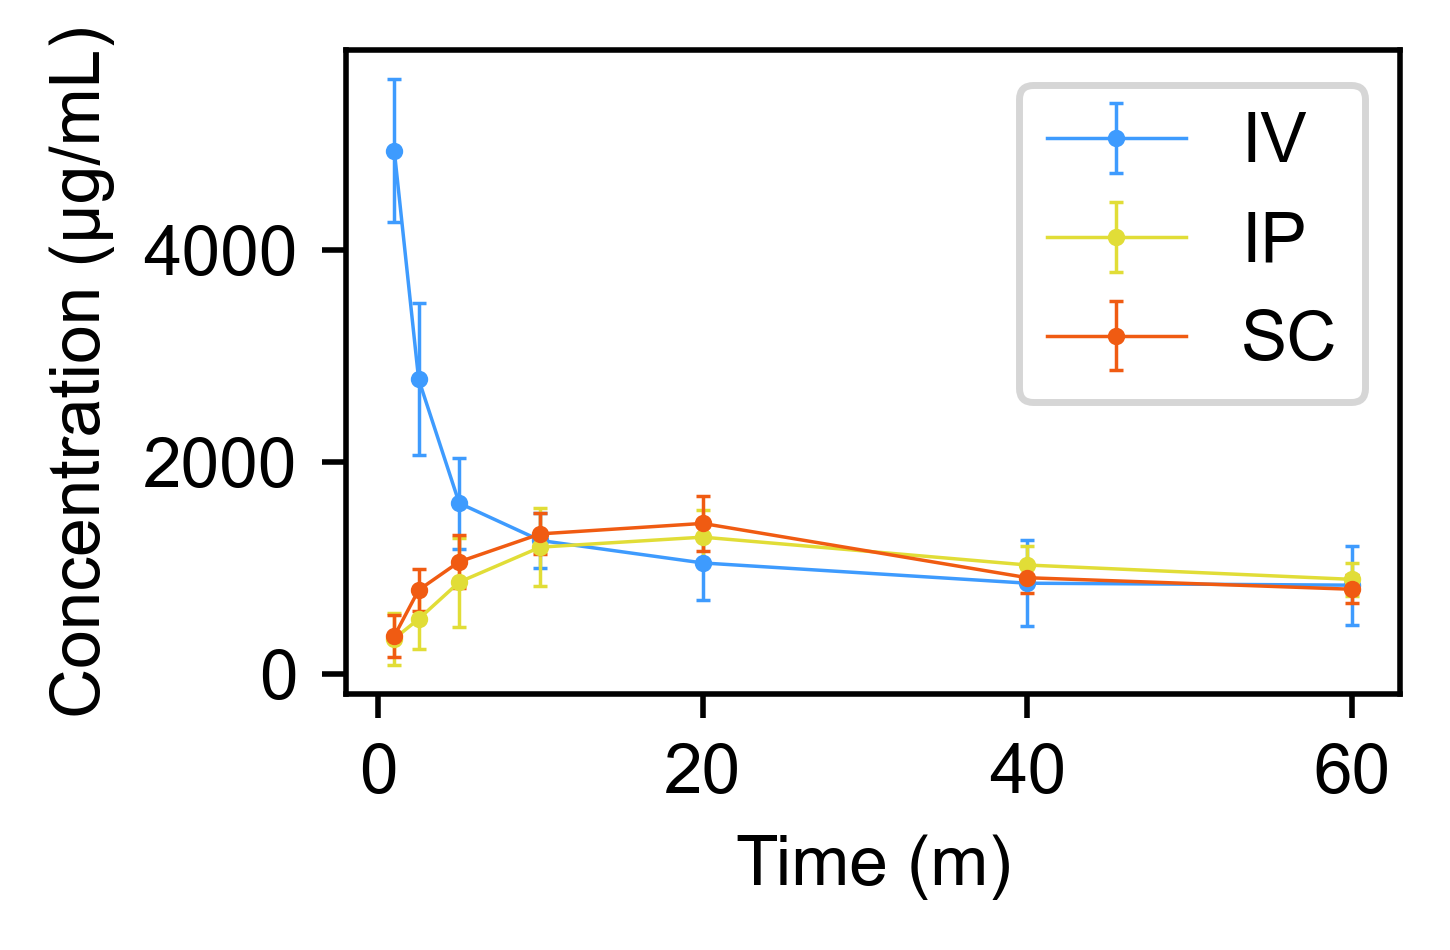

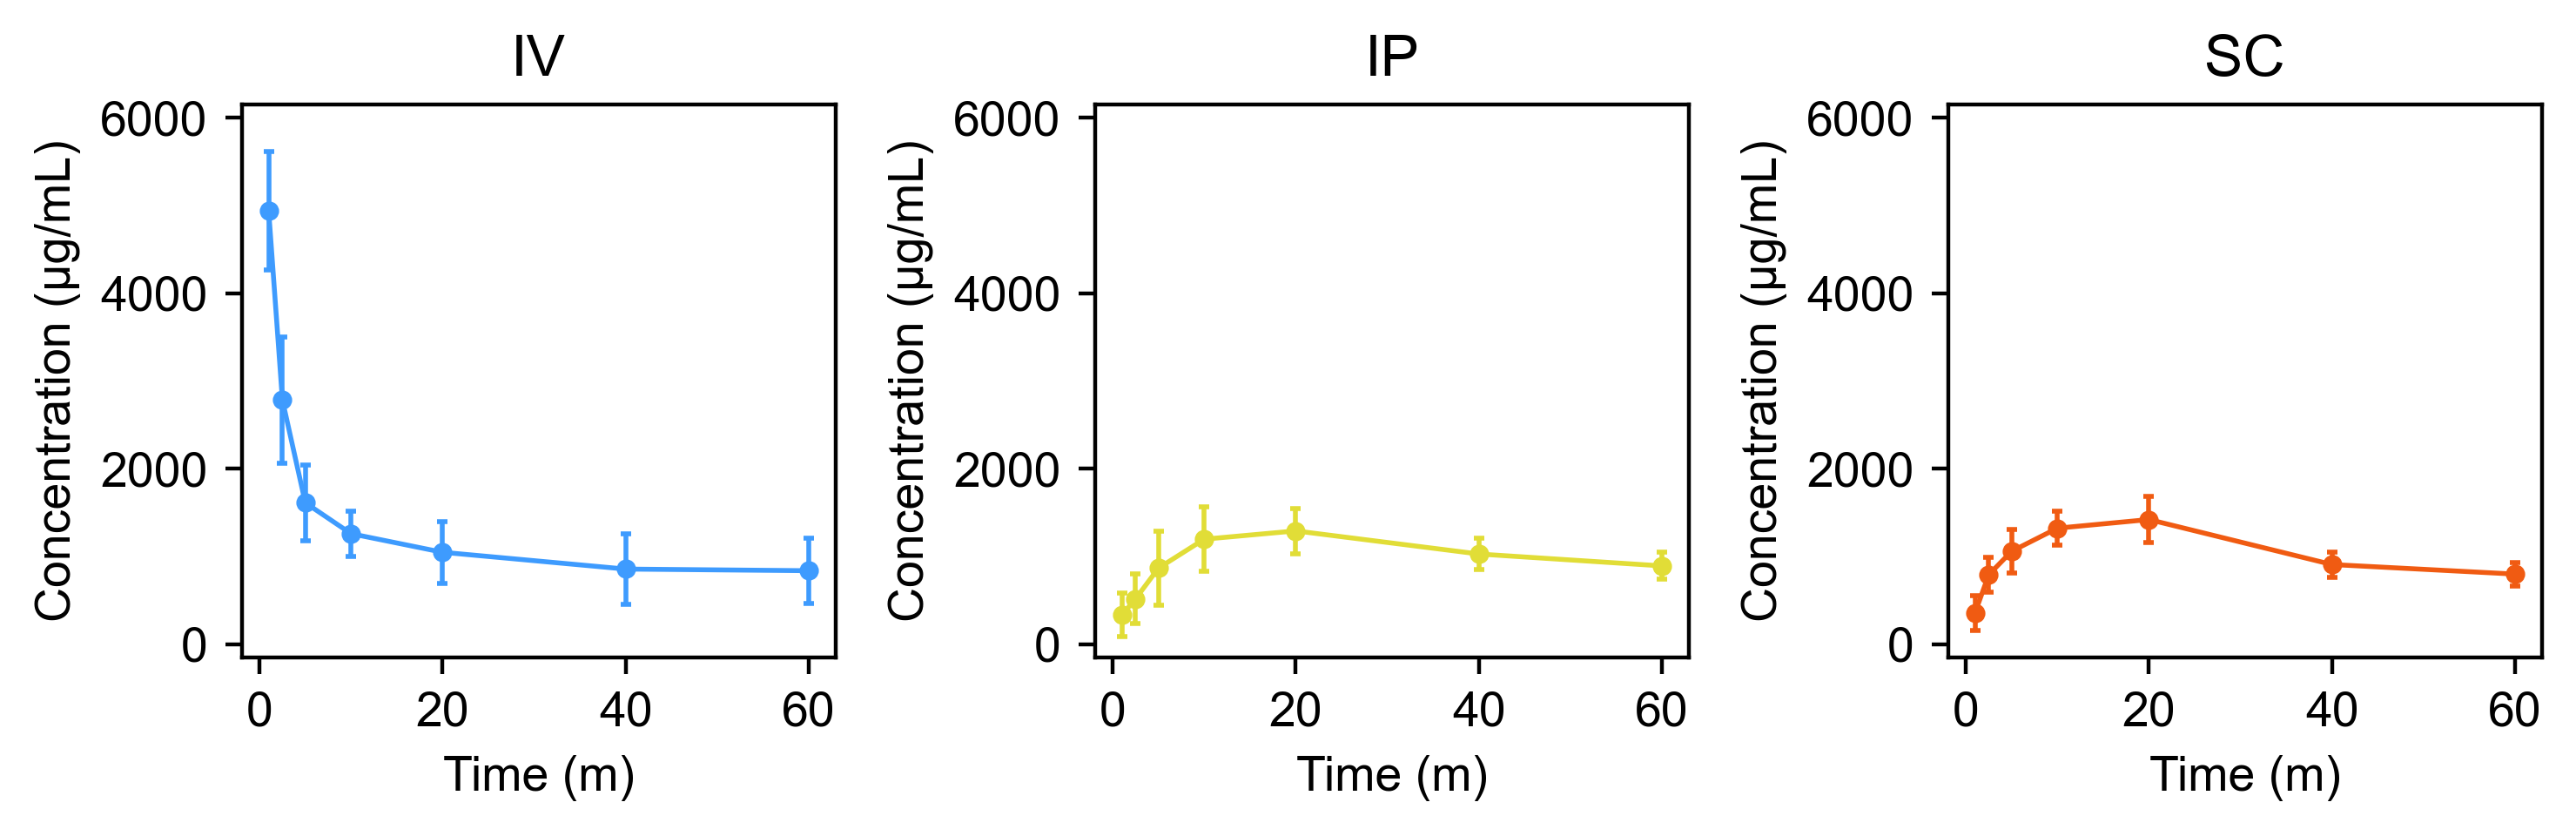

In [33]:
pk_path="/Users/snewbank/Documents/PhD/Data/24-07-24_bloodPKexpt/24-07-24_ketblood_ROAs.csv"

IV=["R1","R4","R7","R10","R13","R14"]
SC=["R2","R5","R8","R11"]
IP=["R3","R6","R9","R12"]

cmap=plt.get_cmap("turbo")

drops_TF=True
save=True

groups={"IV" : IV, "IP" : IP, "SC" : SC}

coeff_results={}

drops_TF=True
df = load_pk(pk_path,drops=drops_TF)
plt.figure(figsize=(3,2),dpi=500)

df=df*20

cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

for k, key in enumerate(groups.keys()):
    print(key)
    if k>-1:
        sub_df=df[groups[key]]
        m=sub_df.mean(axis=1)
        std=sub_df.std(axis=1)
    plt.plot()
    plt.errorbar(df.index, m, yerr=std, color=colors[k],label=key,linewidth=0.5,capsize=1,markeredgewidth=0.5,markersize=2,marker="o")
    plt.xlabel('Time (m)')
    plt.ylabel('Concentration (μg/mL)')
    plt.legend()

plt.tight_layout()

if save==True:
    plt.savefig(save_path+"pk_no_fit.png",dpi=500)
    

fig, ax = plt.subplots(1,3,figsize=(7.5,2.5),dpi=400)

cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

for k, key in enumerate(groups.keys()):
    print(key)
    if k>-1:
        sub_df=df[groups[key]]
        m=sub_df.mean(axis=1)
        std=sub_df.std(axis=1)
    ax[k].plot()
    ax[k].errorbar(df.index, m, yerr=std, color=colors[k],linewidth=1,capsize=1,markeredgewidth=1,markersize=3,marker="o")
    ax[k].set_xlabel('Time (m)')
    ax[k].set_ylabel('Concentration (μg/mL)')
    ax[k].set_title(key)
    ax[k].set_ylim([-150,6150])

plt.tight_layout()

if save==True:
    plt.savefig(save_path+"pk_no_fit_panel.png",dpi=500)

In [9]:
# pk_path="/Users/snewbank/Documents/PhD/Data/24-07-24_bloodPKexpt/24-07-24_ketblood_ROAs.csv"
# 
# IV=["R1","R4","R7","R10","R13","R14"]
# SC=["R2","R5","R8","R11"]
# IP=["R3","R6","R9","R12"]
# 
# cmap=plt.get_cmap("turbo")
# 
# drops_TF=True
# save=True
# 
# groups={"IV" : IV, "IP" : IP, "SC" : SC}
# 
# coeff_results={}
# 
# drops_TF=True
# df = load_pk(pk_path,drops=drops_TF)
# plt.figure(figsize=(3,2),dpi=500)
# 
# df=df*20
# 
# cmap=plt.get_cmap("turbo")
# colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]
# 
# #biexponential
# def f(x, a,alpha,b,beta):
#     return a*np.exp(-alpha*x)+b*np.exp(-beta*x)
# 
# for k, key in enumerate(groups.keys()):
#     print(key)
#     if k>-1:
#         sub_df=df[groups[key]]
#         k_label=False
#         coeff_all=[]
#         labeled=False
#         y_all=[]
#         for col_num, column in enumerate(sub_df.columns):
#             if len(sub_df[column].T.values[~np.isnan(sub_df[column].T.values)])>1:
#                 x_dat=[]
#                 y_dat=[]
#                 for idx, y in enumerate(sub_df[column].T.values):
#                     if not np.isnan(y):
#                         x_dat.append(sub_df.index[idx])
#                         y_dat.append(y)
#     
#                 coeff, _ = scipy.optimize.curve_fit(f,x_dat,y_dat,p0=[1000, 0.1, 1000, 1])
#                 if labeled==False:
#                     plt.scatter(x_dat,y_dat,color=colors[k],s=10,label=key,alpha=0.7,edgecolor="none")
#                     labeled=True
#                 else:
#                     plt.scatter(x_dat,y_dat,color=colors[k],s=10,alpha=0.7,edgecolor="none")
#                 x = np.linspace(0, 60, 120)
#                 y = f(x,*coeff)
#                 y_all.append(y)
#                 coeff_all.append(coeff)
#                 print(coeff)
#                 #plt.plot(x, y, color=colors[k],linewidth=0.5)
#     coeff_results[key]=coeff_all
#     x = np.linspace(0, 60, 120)
#     y_m = np.mean(np.array(y_all),axis=0)
#     y_std = np.std(np.array(y_all),axis=0)
#     plt.plot(x, y_m, color=colors[k],linewidth=0.5)
#     plt.fill_between(x, y_m-y_std, y_m+y_std, color=colors[k],alpha=0.2,edgecolor="none")
#     plt.xlabel('Time (m)')
#     plt.ylabel('Concentration (μg/mL)')
#     plt.legend()
# 
# plt.tight_layout()
# 
# # if save==True:
# #     plt.savefig(save_path+"pk_fitting.png",dpi=500)

IV


/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/308863463.py:27: RuntimeWarning: overflow encountered in exp
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/308863463.py:27: RuntimeWarning: overflow encountered in multiply
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/308863463.py:27: RuntimeWarning: invalid value encountered in add
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)


IP


/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/308863463.py:27: RuntimeWarning: overflow encountered in exp
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/308863463.py:27: RuntimeWarning: overflow encountered in multiply
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/308863463.py:27: RuntimeWarning: invalid value encountered in add
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)


SC


/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/308863463.py:27: RuntimeWarning: overflow encountered in exp
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/308863463.py:27: RuntimeWarning: overflow encountered in multiply
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/308863463.py:27: RuntimeWarning: invalid value encountered in add
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)


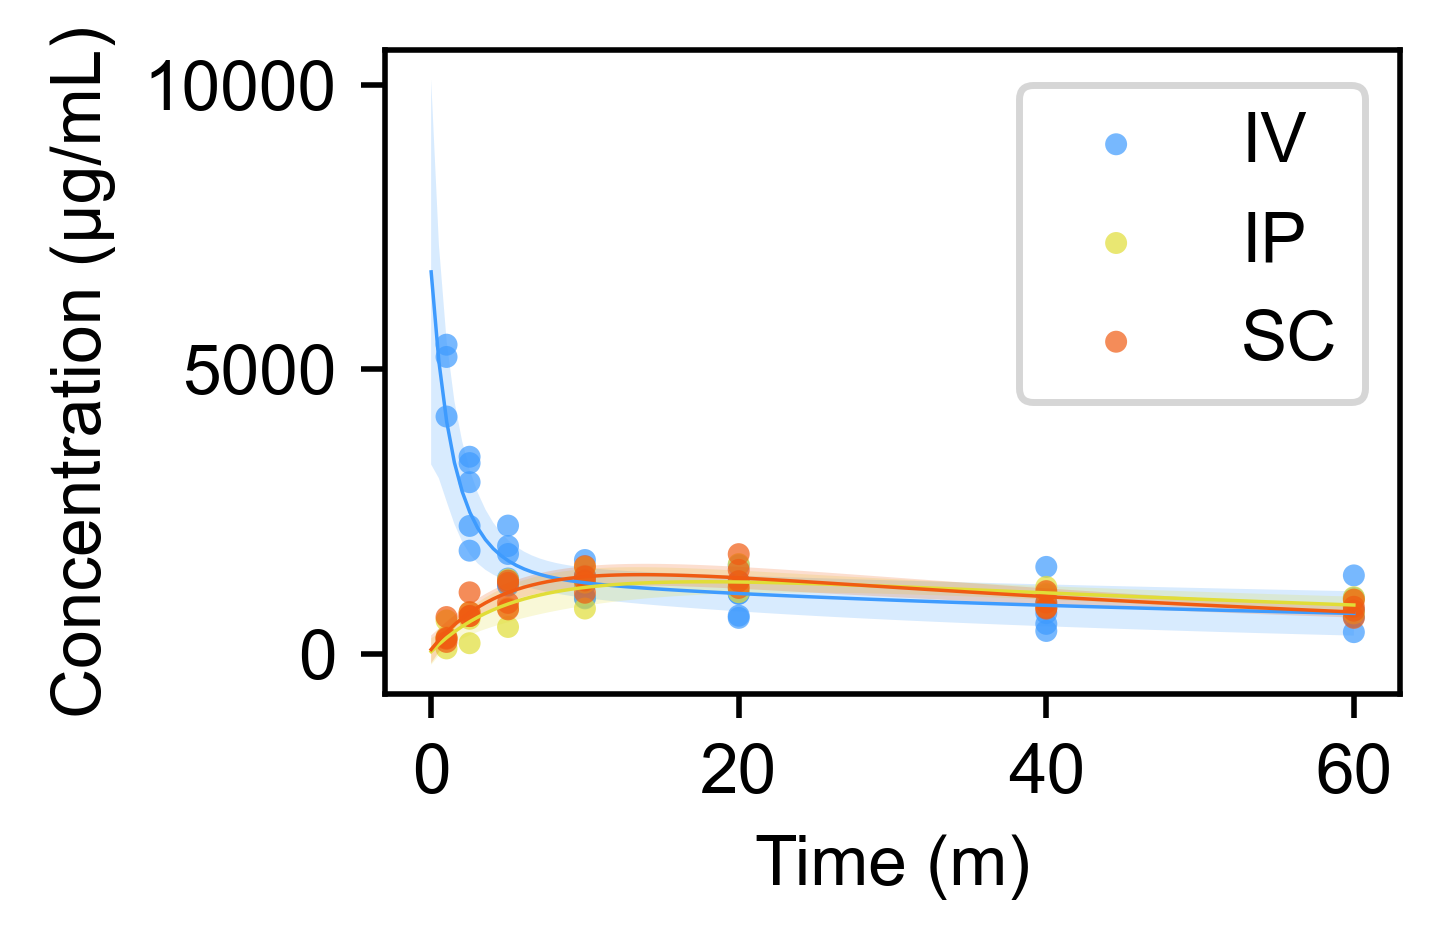

In [11]:
pk_path="/Users/snewbank/Documents/PhD/Data/24-07-24_bloodPKexpt/24-07-24_ketblood_ROAs.csv"

IV=["R1","R4","R7","R10","R13","R14"]
SC=["R2","R5","R8","R11"]
IP=["R3","R6","R9","R12"]

cmap=plt.get_cmap("turbo")

drops_TF=True
save=True

groups={"IV" : IV, "IP" : IP, "SC" : SC}

coeff_results={}

drops_TF=True
df = load_pk(pk_path,drops=drops_TF)
plt.figure(figsize=(3,2),dpi=500)

df=df*20

cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

#biexponential
def f(x, a,alpha,b,beta):
    return a*np.exp(-alpha*x)+b*np.exp(-beta*x)

def optimize_p0(f,x,y):
    a_values = np.linspace(0, 5000, 10)
    b_values = np.linspace(0.1, 0.5, 10)
    c_values = np.linspace(0, 5000, 10)
    d_values = np.linspace(0.1, 0.5, 10)
    
    best_p0 = None
    min_error = np.inf
    
    for a in a_values:
        for b in b_values:
            for c in c_values:
                for d in d_values:
                    p0 = [a, b, c, d]
                    try:
                        coeff, _ = scipy.optimize.curve_fit(f, x, y, p0=p0)
                        y_hat = np.array([f(x_i, *coeff) for x_i in x])
                        error = np.sum((y-y_hat)**2)
                        if error < min_error:
                            min_error = error
                            best_p0 = p0
                    except:
                        continue
    return best_p0

grid_search = True

for k, key in enumerate(groups.keys()):
    print(key)
    if k>-1:
        sub_df=df[groups[key]]
        k_label=False
        coeff_all=[]
        labeled=False
        y_all=[]
        for col_num, column in enumerate(sub_df.columns):
            if len(sub_df[column].T.values[~np.isnan(sub_df[column].T.values)])>1:
                x_dat=[]
                y_dat=[]
                for idx, y in enumerate(sub_df[column].T.values):
                    if not np.isnan(y):
                        x_dat.append(sub_df.index[idx])
                        y_dat.append(y)
                if grid_search==True:
                    optimal_p0 = optimize_p0(f,x_dat,y_dat)
                else:
                    optimal_p0=[1000, 0.1, 1000, 1]
                coeff, _ = scipy.optimize.curve_fit(f,x_dat,y_dat,p0=optimal_p0)
                if labeled==False:
                    plt.scatter(x_dat,y_dat,color=colors[k],s=10,label=key,alpha=0.7,edgecolor="none")
                    labeled=True
                else:
                    plt.scatter(x_dat,y_dat,color=colors[k],s=10,alpha=0.7,edgecolor="none")
                x = np.linspace(0, 60, 120)
                y = f(x,*coeff)
                y_all.append(y)
                coeff_all.append(coeff)
                #print(coeff)
                #plt.plot(x, y, color=colors[k],linewidth=0.5)
    coeff_results[key]=coeff_all
    x = np.linspace(0, 60, 120)
    y_m = np.mean(np.array(y_all),axis=0)
    y_std = np.std(np.array(y_all),axis=0)
    plt.plot(x, y_m, color=colors[k],linewidth=0.5)
    plt.fill_between(x, y_m-y_std, y_m+y_std, color=colors[k],alpha=0.2,edgecolor="none")
    plt.xlabel('Time (m)')
    plt.ylabel('Concentration (μg/mL)')
    plt.legend()

plt.tight_layout()

if save==True:
    plt.savefig(save_path+"pk_fitting.png",dpi=500)

IV


/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/2220772987.py:27: RuntimeWarning: overflow encountered in exp
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/2220772987.py:27: RuntimeWarning: overflow encountered in multiply
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/2220772987.py:27: RuntimeWarning: invalid value encountered in add
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)


IP


/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/2220772987.py:27: RuntimeWarning: overflow encountered in exp
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/2220772987.py:27: RuntimeWarning: overflow encountered in multiply
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/2220772987.py:27: RuntimeWarning: invalid value encountered in add
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)


SC


/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/2220772987.py:27: RuntimeWarning: overflow encountered in exp
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/2220772987.py:27: RuntimeWarning: overflow encountered in multiply
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/2220772987.py:27: RuntimeWarning: invalid value encountered in add
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)


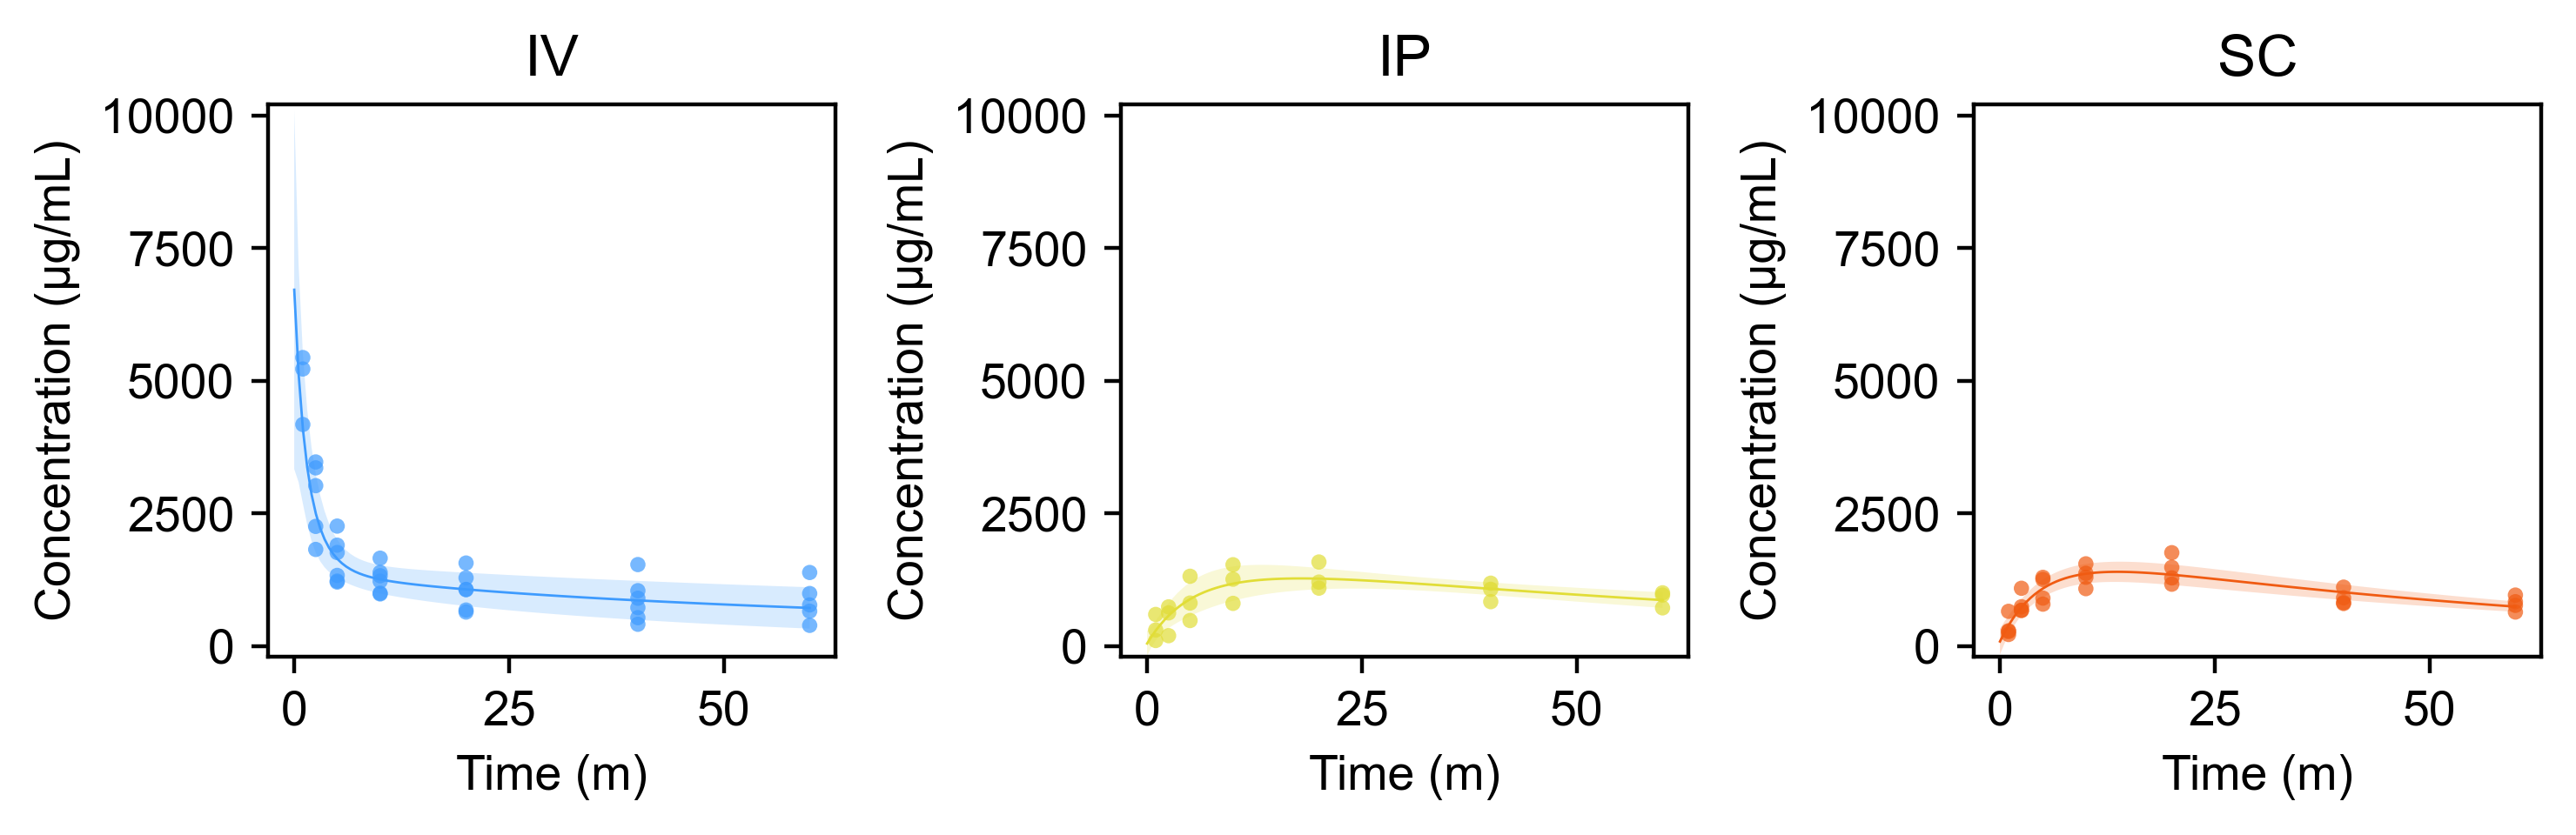

In [34]:
pk_path="/Users/snewbank/Documents/PhD/Data/24-07-24_bloodPKexpt/24-07-24_ketblood_ROAs.csv"

IV=["R1","R4","R7","R10","R13","R14"]
SC=["R2","R5","R8","R11"]
IP=["R3","R6","R9","R12"]

cmap=plt.get_cmap("turbo")

drops_TF=True
save=True

groups={"IV" : IV, "IP" : IP, "SC" : SC}

coeff_results={}

drops_TF=True
df = load_pk(pk_path,drops=drops_TF)
fig, ax = plt.subplots(1,3,figsize=(7.5,2.5),dpi=400)

df=df*20

cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

#biexponential
def f(x, a,alpha,b,beta):
    return a*np.exp(-alpha*x)+b*np.exp(-beta*x)

def optimize_p0(f,x,y):
    a_values = np.linspace(0, 5000, 10)
    b_values = np.linspace(0.1, 0.5, 10)
    c_values = np.linspace(0, 5000, 10)
    d_values = np.linspace(0.1, 0.5, 10)
    
    best_p0 = None
    min_error = np.inf
    
    for a in a_values:
        for b in b_values:
            for c in c_values:
                for d in d_values:
                    p0 = [a, b, c, d]
                    try:
                        coeff, _ = scipy.optimize.curve_fit(f, x, y, p0=p0)
                        y_hat = np.array([f(x_i, *coeff) for x_i in x])
                        error = np.sum((y-y_hat)**2)
                        if error < min_error:
                            min_error = error
                            best_p0 = p0
                    except:
                        continue
    return best_p0

grid_search = True

for k, key in enumerate(groups.keys()):
    print(key)
    if k>-1:
        sub_df=df[groups[key]]
        k_label=False
        coeff_all=[]
        labeled=False
        y_all=[]
        for col_num, column in enumerate(sub_df.columns):
            if len(sub_df[column].T.values[~np.isnan(sub_df[column].T.values)])>1:
                x_dat=[]
                y_dat=[]
                for idx, y in enumerate(sub_df[column].T.values):
                    if not np.isnan(y):
                        x_dat.append(sub_df.index[idx])
                        y_dat.append(y)
                if grid_search==True:
                    optimal_p0 = optimize_p0(f,x_dat,y_dat)
                else:
                    optimal_p0=[1000, 0.1, 1000, 1]
                coeff, _ = scipy.optimize.curve_fit(f,x_dat,y_dat,p0=optimal_p0)
                ax[k].scatter(x_dat,y_dat,color=colors[k],s=10,alpha=0.7,edgecolor="none")
                x = np.linspace(0, 60, 120)
                y = f(x,*coeff)
                y_all.append(y)
                coeff_all.append(coeff)
                #print(coeff)
                #plt.plot(x, y, color=colors[k],linewidth=0.5)
    coeff_results[key]=coeff_all
    x = np.linspace(0, 60, 120)
    y_m = np.mean(np.array(y_all),axis=0)
    y_std = np.std(np.array(y_all),axis=0)
    ax[k].plot(x, y_m, color=colors[k],linewidth=0.5)
    ax[k].fill_between(x, y_m-y_std, y_m+y_std, color=colors[k],alpha=0.2,edgecolor="none")
    ax[k].set_xlabel('Time (m)')
    ax[k].set_ylabel('Concentration (μg/mL)')
    ax[k].set_title(key)
    ax[k].set_ylim([-200,10200])
    #plt.legend()

plt.tight_layout()

if save==True:
    plt.savefig(save_path+"pk_fitting_panels.png",dpi=500)

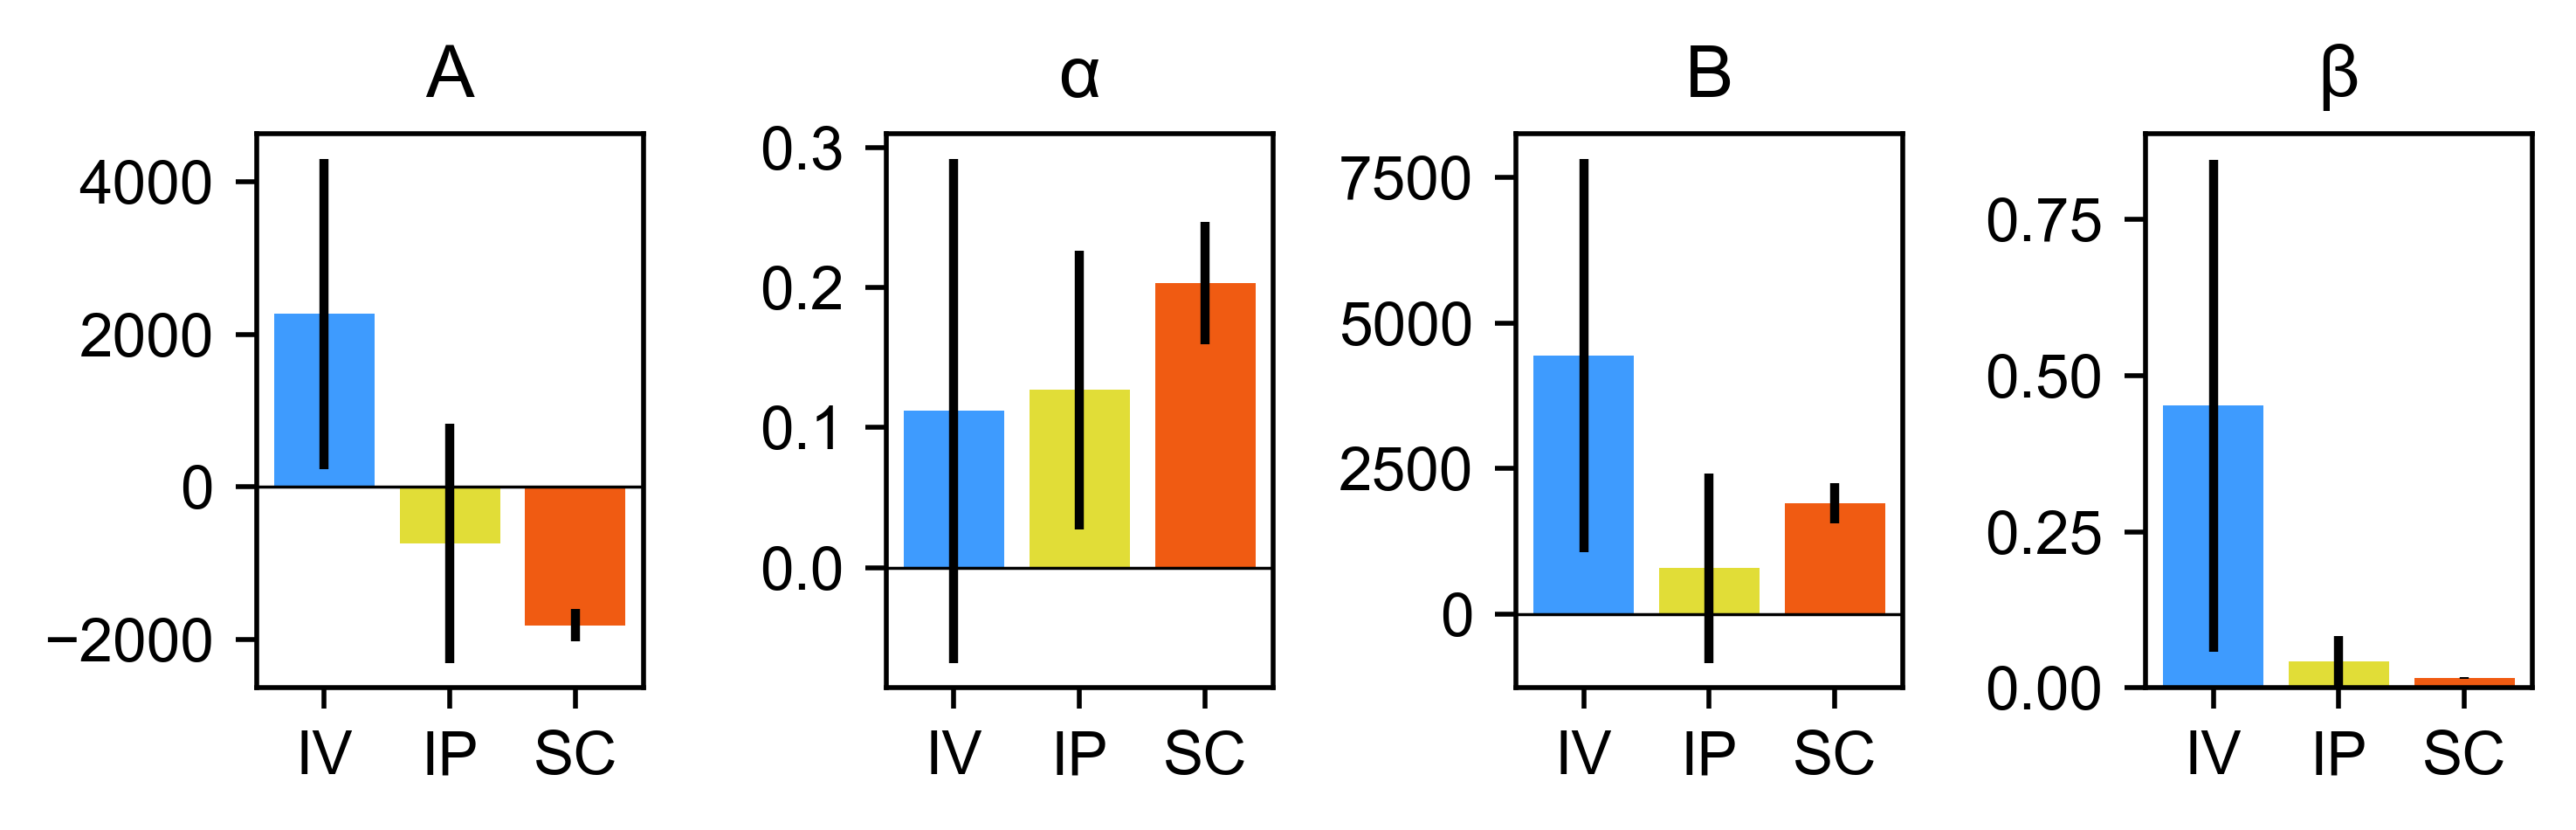

In [12]:
coeffs=4
fig, ax = plt.subplots(1,coeffs,figsize=(6,2),dpi=500)
ticks=[]
labels=[]
cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]
coeff_names=["Α","α","Β","β"]
for k, key in enumerate(coeff_results.keys()):
    array=np.array(coeff_results[key])
    mean=np.mean(array,axis=0)
    std=np.std(array,axis=0)
    ticks.append(k)
    labels.append(key)
    for coeff in range(coeffs):
        ax[coeff].bar(x=k,height=mean[coeff],color=colors[k])
        ax[coeff].errorbar(k,mean[coeff],yerr=std[coeff],color="black")

for coeff in range(coeffs):
    ax[coeff].set_xticks(ticks)
    ax[coeff].set_xticklabels(labels)
    ax[coeff].set_title(coeff_names[coeff])
    ax[coeff].axhline(0,color="black",linewidth=0.5)
    
plt.tight_layout()

if save==True:
    plt.savefig(save_path+"pk_fit_params.png",dpi=500)

In [245]:
importlib.reload(analysis)
importlib.reload(plot)

config_path="/Users/snewbank/Behavior/MARIPOSA_test/240730_vame-all/config_pk.yaml"
save_path="/Users/snewbank/Behavior/MARIPOSA_test/240730_vame-all/demo_pk/"
save=False

#Load config
config = metadata.load_project(config_path)

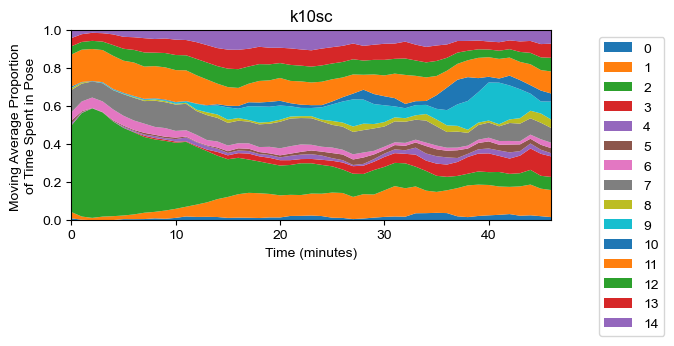

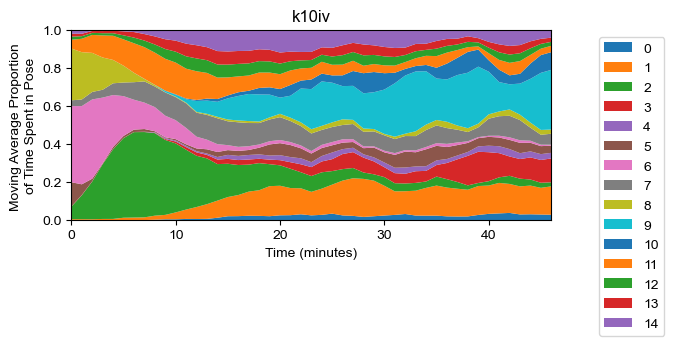

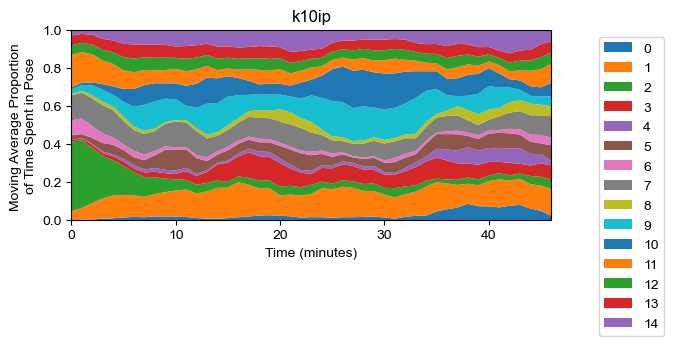

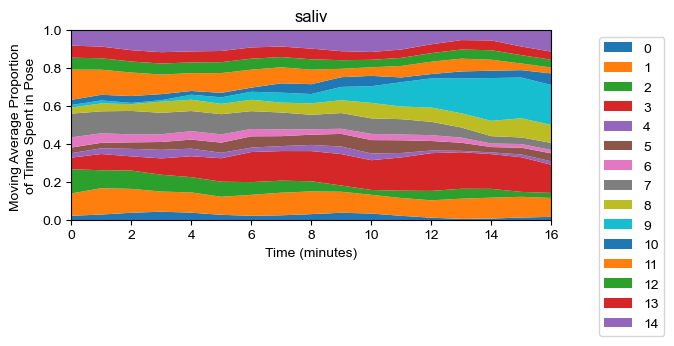

In [39]:
group="k10sc"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 50,title=group)
plt.savefig(save_path+group+"_sandplot.png",dpi=500)
group="k10iv"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 50,title=group)
plt.savefig(save_path+group+"_sandplot.png",dpi=500)
group="k10ip"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 50,title=group)
plt.savefig(save_path+group+"_sandplot.png",dpi=500)
group="saliv"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*20,selected_subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 20,title=group)
plt.savefig(save_path+group+"_sandplot.png",dpi=500)

done with ['2023-07-18_18-19-50_bm04_k10iv_2023-07-18_18-19-50_bm04_k10iv.csv', '2023-07-18_18-19-50_bm04_k10iv']
done with ['2023-06-20_19-10-38_bf04_k1iv_2023-06-20_19-10-38_bf04_k1iv.csv', '2023-06-20_19-10-38_bf04_k1iv']
VAME modules map onto scored behaviors with 'loss' of 0.42009361417586094
Applying 15 remapping rules from config.
1 of 15: Remapping [0] to groom
2 of 15: Remapping [1] to explore
3 of 15: Remapping [2] to walk
4 of 15: Remapping [3] to ataxic 4-5
5 of 15: Remapping [4] to groom
6 of 15: Remapping [5] to ataxic 4-5
7 of 15: Remapping [6] to ataxic 4-5
8 of 15: Remapping [7] to explore
9 of 15: Remapping [8] to sleep
10 of 15: Remapping [9] to ataxic 1-3
11 of 15: Remapping [10] to explore
12 of 15: Remapping [11] to walk
13 of 15: Remapping [12] to rear
14 of 15: Remapping [13] to rear
15 of 15: Remapping [14] to rear
Applying 15 remapping rules from config.
1 of 15: Remapping [0] to groom
2 of 15: Remapping [1] to explore
3 of 15: Remapping [2] to walk
4 of 15: R

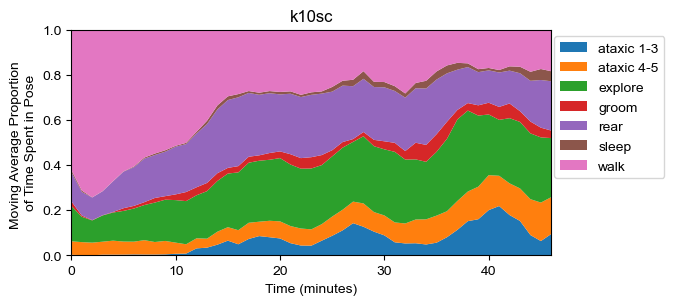

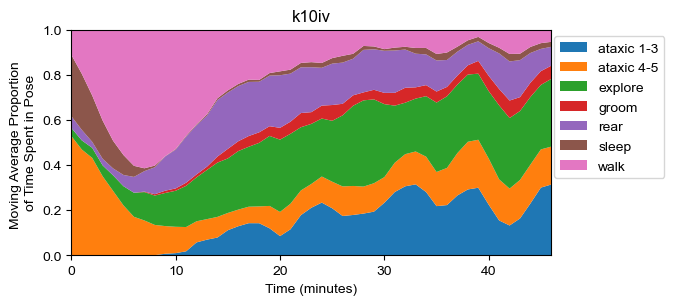

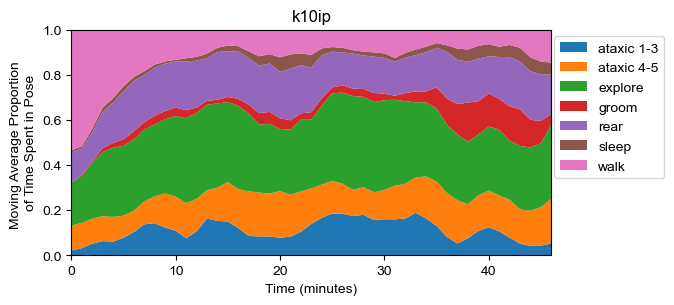

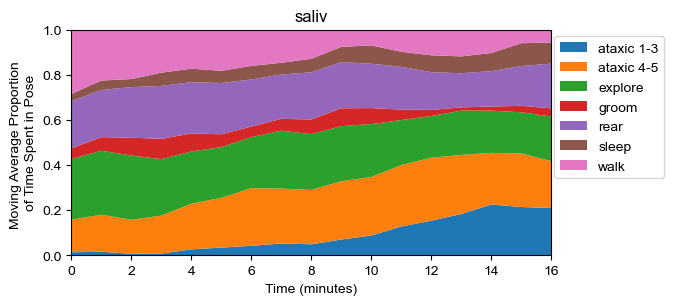

In [40]:
BORIS_to_pose_mat, BORIS_to_pose_mat_normalized, loss = analysis.BORIS_to_pose(config)

group="k10sc"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
labels_df = analysis.make_remappings_from_BORIS(config, labels_df, BORIS_to_pose_mat)
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 50,title=group)
plt.savefig(save_path+group+"_remapped_sandplot.png",dpi=500)
group="k10iv"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
labels_df = analysis.make_remappings_from_BORIS(config, labels_df, BORIS_to_pose_mat)
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 50,title=group)
plt.savefig(save_path+group+"_remapped_sandplot.png",dpi=500)
group="k10ip"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
labels_df = analysis.make_remappings_from_BORIS(config, labels_df, BORIS_to_pose_mat)
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 50,title=group)
plt.savefig(save_path+group+"_remapped_sandplot.png",dpi=500)
group="saliv"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*20,selected_subgroups=[group])
labels_df = analysis.make_remappings_from_BORIS(config, labels_df, BORIS_to_pose_mat)
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 20,title=group)
plt.savefig(save_path+group+"_remapped_sandplot.png",dpi=500)

Text(0.5, 0, 'Time (m)')

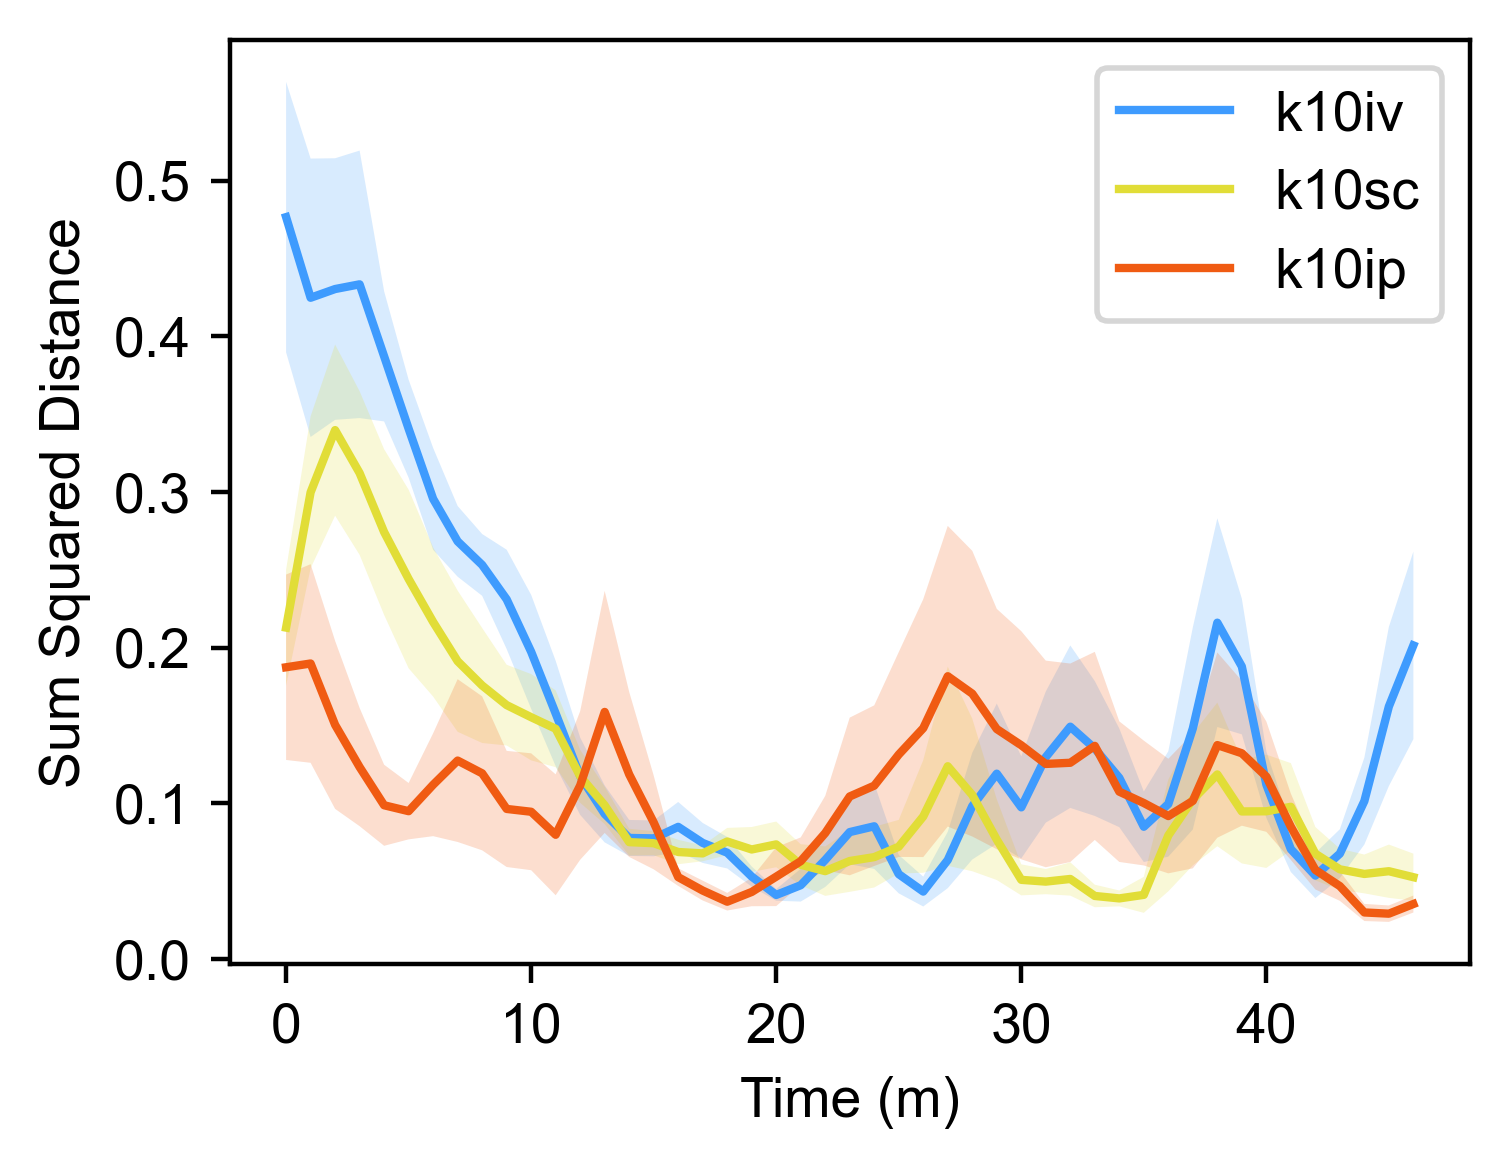

In [249]:
groups=["k10iv","k10sc","k10ip"]
cmap = plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

plt.figure(figsize=(4,3),dpi=400)
for g, group in enumerate(groups):
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
    block_labels_normal_unconv, block_labels_normal = module_usage_density(config, labels_df[group],0, 60, 50)
    block_labels_normal.shape
    
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=["saliv"])
    label_counts=module_usage_dist(config,labels_df)
    mean_label_counts=np.mean(label_counts,axis=0)
    
    mean_label_counts_block = np.expand_dims(mean_label_counts, axis=1)
    mean_label_counts_block = np.tile(mean_label_counts_block, (1, block_labels_normal.shape[2]))
    
    out=np.zeros_like(block_labels_normal)
    for sess in range(block_labels_normal.shape[0]):
        out[sess,:,:]=np.square(block_labels_normal[sess,:,:]-mean_label_counts_block)
    
    dist=np.sum(out,axis=1)
    xpts=np.arange(0,dist.shape[1],1)
    
    mean = np.mean(dist,axis=0)
    sem = np.std(dist,axis=0)/np.sqrt(dist.shape[0])
    
    plt.plot(xpts,mean,label=group,color=colors[g])
    plt.fill_between(xpts,mean-sem,mean+sem,alpha=0.2,color=colors[g],edgecolor="none")
plt.legend()
plt.ylabel("Sum Squared Distance")
plt.xlabel("Time (m)")

In [ ]:
#biexponential
def f(x, a,alpha,b,beta):
    return a*np.exp(-alpha*x)+b*np.exp(-beta*x)

for k, key in enumerate(groups.keys()):
    print(key)
    if k>-1:
        sub_df=df[groups[key]]
        k_label=False
        coeff_all=[]
        labeled=False
        y_all=[]
        for col_num, column in enumerate(sub_df.columns):
            if len(sub_df[column].T.values[~np.isnan(sub_df[column].T.values)])>1:
                x_dat=[]
                y_dat=[]
                for idx, y in enumerate(sub_df[column].T.values):
                    if not np.isnan(y):
                        x_dat.append(sub_df.index[idx])
                        y_dat.append(y)
    
                coeff, _ = scipy.optimize.curve_fit(f,x_dat,y_dat,p0=[1000, 0.1, 1000, 1])
                if labeled==False:
                    plt.scatter(x_dat,y_dat,color=colors[k],s=10,label=key,alpha=0.7,edgecolor="none")
                    labeled=True
                else:
                    plt.scatter(x_dat,y_dat,color=colors[k],s=10,alpha=0.7,edgecolor="none")
                x = np.linspace(0, 60, 120)
                y = f(x,*coeff)
                y_all.append(y)
                coeff_all.append(coeff)
                print(coeff)
                #plt.plot(x, y, color=colors[k],linewidth=0.5)
    coeff_results[key]=coeff_all
    x = np.linspace(0, 60, 120)

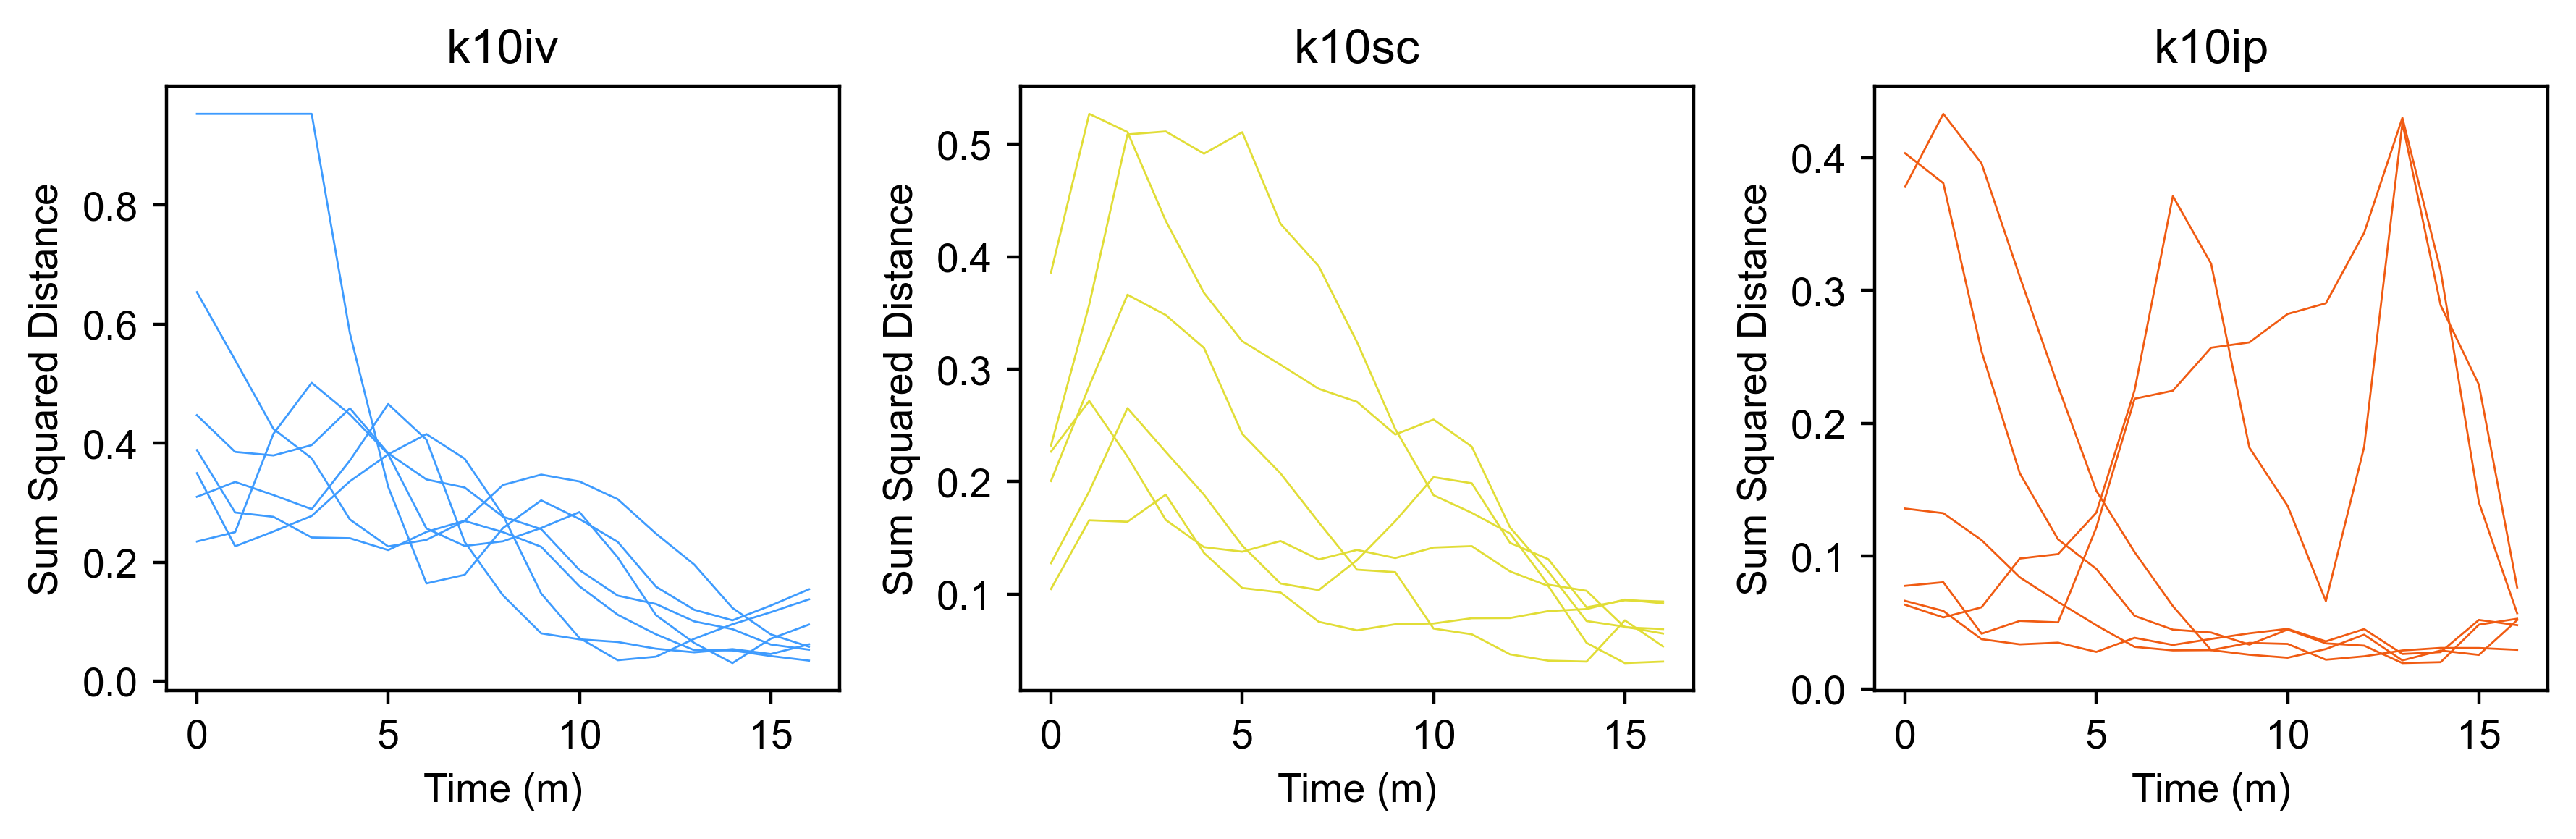

In [271]:
groups=["k10iv","k10sc","k10ip"]
cmap = plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

fig, ax = plt.subplots(1,3,figsize=(9,3),dpi=400)
for g, group in enumerate(groups):
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*20,selected_subgroups=[group])
    block_labels_normal_unconv, block_labels_normal = module_usage_density(config, labels_df[group],0, 60, 20)
    block_labels_normal.shape
    
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=["saliv"])
    label_counts=module_usage_dist(config,labels_df)
    mean_label_counts=np.mean(label_counts,axis=0)
    
    mean_label_counts_block = np.expand_dims(mean_label_counts, axis=1)
    mean_label_counts_block = np.tile(mean_label_counts_block, (1, block_labels_normal.shape[2]))
    
    out=np.zeros_like(block_labels_normal)
    for sess in range(block_labels_normal.shape[0]):
        out[sess,:,:]=np.square(block_labels_normal[sess,:,:]-mean_label_counts_block)
    
    dist=np.sum(out,axis=1)
    xpts=np.arange(0,dist.shape[1],1)
    
    mean = np.mean(dist,axis=0)
    sem = np.std(dist,axis=0)/np.sqrt(dist.shape[0])
    for sess in range(dist.shape[0]):
        ax[g].plot(xpts,dist[sess,:],label=group,color=colors[g],linewidth=0.5)
    #plt.fill_between(xpts,mean-sem,mean+sem,alpha=0.2,color=colors[g],edgecolor="none")
    ax[g].set_title(group)
    ax[g].set_ylabel("Sum Squared Distance")
    ax[g].set_xlabel("Time (m)")
plt.tight_layout()

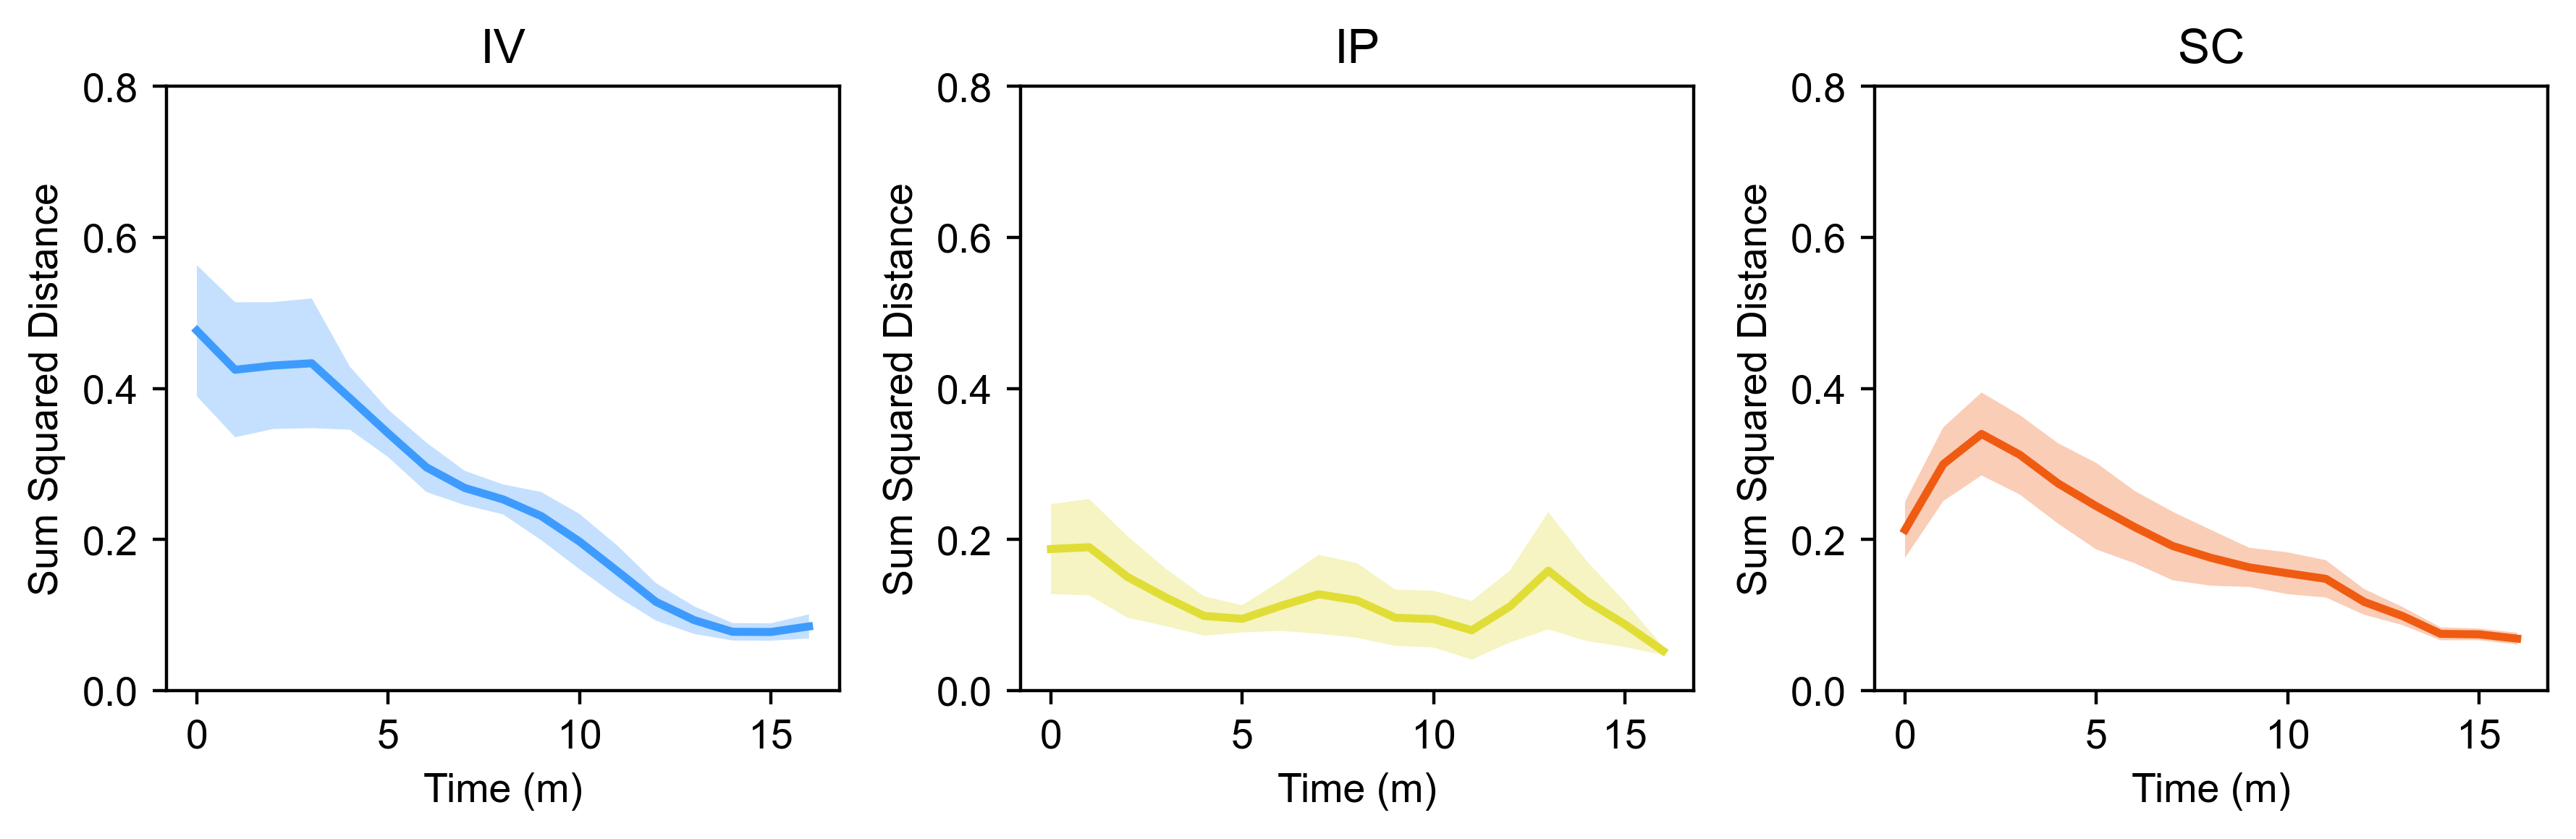

In [85]:
groups=["k10iv","k10ip","k10sc"]
cmap = plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]
groupnames=["IV","IP","SC"]

fig, ax = plt.subplots(1,3,figsize=(9,3),dpi=400)
for g, group in enumerate(groups):
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*20,selected_subgroups=[group])
    block_labels_normal_unconv, block_labels_normal = module_usage_density(config, labels_df[group],0, 60, 20)
    block_labels_normal.shape
    
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=["saliv"])
    label_counts=module_usage_dist(config,labels_df)
    mean_label_counts=np.mean(label_counts,axis=0)
    
    mean_label_counts_block = np.expand_dims(mean_label_counts, axis=1)
    mean_label_counts_block = np.tile(mean_label_counts_block, (1, block_labels_normal.shape[2]))
    
    out=np.zeros_like(block_labels_normal)
    for sess in range(block_labels_normal.shape[0]):
        out[sess,:,:]=np.square(block_labels_normal[sess,:,:]-mean_label_counts_block)
    
    dist=np.sum(out,axis=1)
    xpts=np.arange(0,dist.shape[1],1)
    
    mean = np.mean(dist,axis=0)
    sem = np.std(dist,axis=0)/np.sqrt(dist.shape[0])
    # for sess in range(dist.shape[0]):
    #     ax[g].plot(xpts,dist[sess,:],label=group,color=colors[g],linewidth=0.5)
    #plt.fill_between(xpts,mean-sem,mean+sem,alpha=0.2,color=colors[g],edgecolor="none")
    ax[g].plot(xpts,mean,label=group,color=colors[g],linewidth=2)
    ax[g].fill_between(xpts,mean-sem,mean+sem,color=colors[g],alpha=0.3,edgecolor="none")
    ax[g].set_title(group)
    ax[g].set_ylabel("Sum Squared Distance")
    ax[g].set_xlabel("Time (m)")
    ax[g].set_ylim([0,0.8])
    ax[g].set_title(groupnames[g])
plt.tight_layout()

if save==True:
    plt.savefig(save_path+"behavior_SSD_plots.png",dpi=500)

IV


/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/1562204440.py:8: RuntimeWarning: overflow encountered in exp
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/1562204440.py:8: RuntimeWarning: invalid value encountered in add
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/1562204440.py:8: RuntimeWarning: overflow encountered in multiply
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)


[0.11419764 0.92581756 0.54449065 0.13639948]
[-3.19573228e+02  2.24687409e-01  3.19830468e+02  2.24259912e-01]
[ 3.77617788e+02  2.64917228e-01 -3.77417006e+02  2.65564575e-01]
[-191.60712719    0.22637671  192.00247498    0.22560905]
[-275.64553278    0.29160637  275.91240361    0.2908373 ]
[-0.46909016  1.35685406  1.41217837  0.21262182]
[-0.00126111 -0.34531193  0.28312669 -0.01119042]
IP


/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/1562204440.py:8: RuntimeWarning: overflow encountered in exp
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/1562204440.py:8: RuntimeWarning: invalid value encountered in add
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/1562204440.py:8: RuntimeWarning: overflow encountered in multiply
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)


[ 4.38404538e-01  3.05175655e-01  2.99337893e-04 -3.20071780e-01]
[-1.15071875 -0.27893924  1.19997511 -0.27633511]
[-4.93342271e-10 -1.26277126e+00  9.46040031e-02 -8.45539503e-02]
[ 1.33464642  0.40350761 -0.95966862  0.76493417]
[ 0.04064277  0.62398075  0.02819259 -0.02755856]
[ 0.00142079 -0.18876262  0.14815299  0.21624244]
SC


/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/1562204440.py:8: RuntimeWarning: overflow encountered in exp
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/1562204440.py:8: RuntimeWarning: invalid value encountered in add
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_23113/1562204440.py:8: RuntimeWarning: overflow encountered in multiply
  return a*np.exp(-alpha*x)+b*np.exp(-beta*x)


[-0.23785103  2.25471886  0.62362447  0.1154801 ]
[-0.83441792  0.54153962  1.02362314  0.23962696]
[-0.10612399  2.04272869  0.23254218  0.0501973 ]
[-2.68267995e-06 -6.17770651e-01  2.33937161e-01  6.58371334e-02]
[-0.06932334 23.92491564  0.17381063  0.06642882]
[-3.17098086e+02  2.76515012e-01  3.17303422e+02  2.75474202e-01]


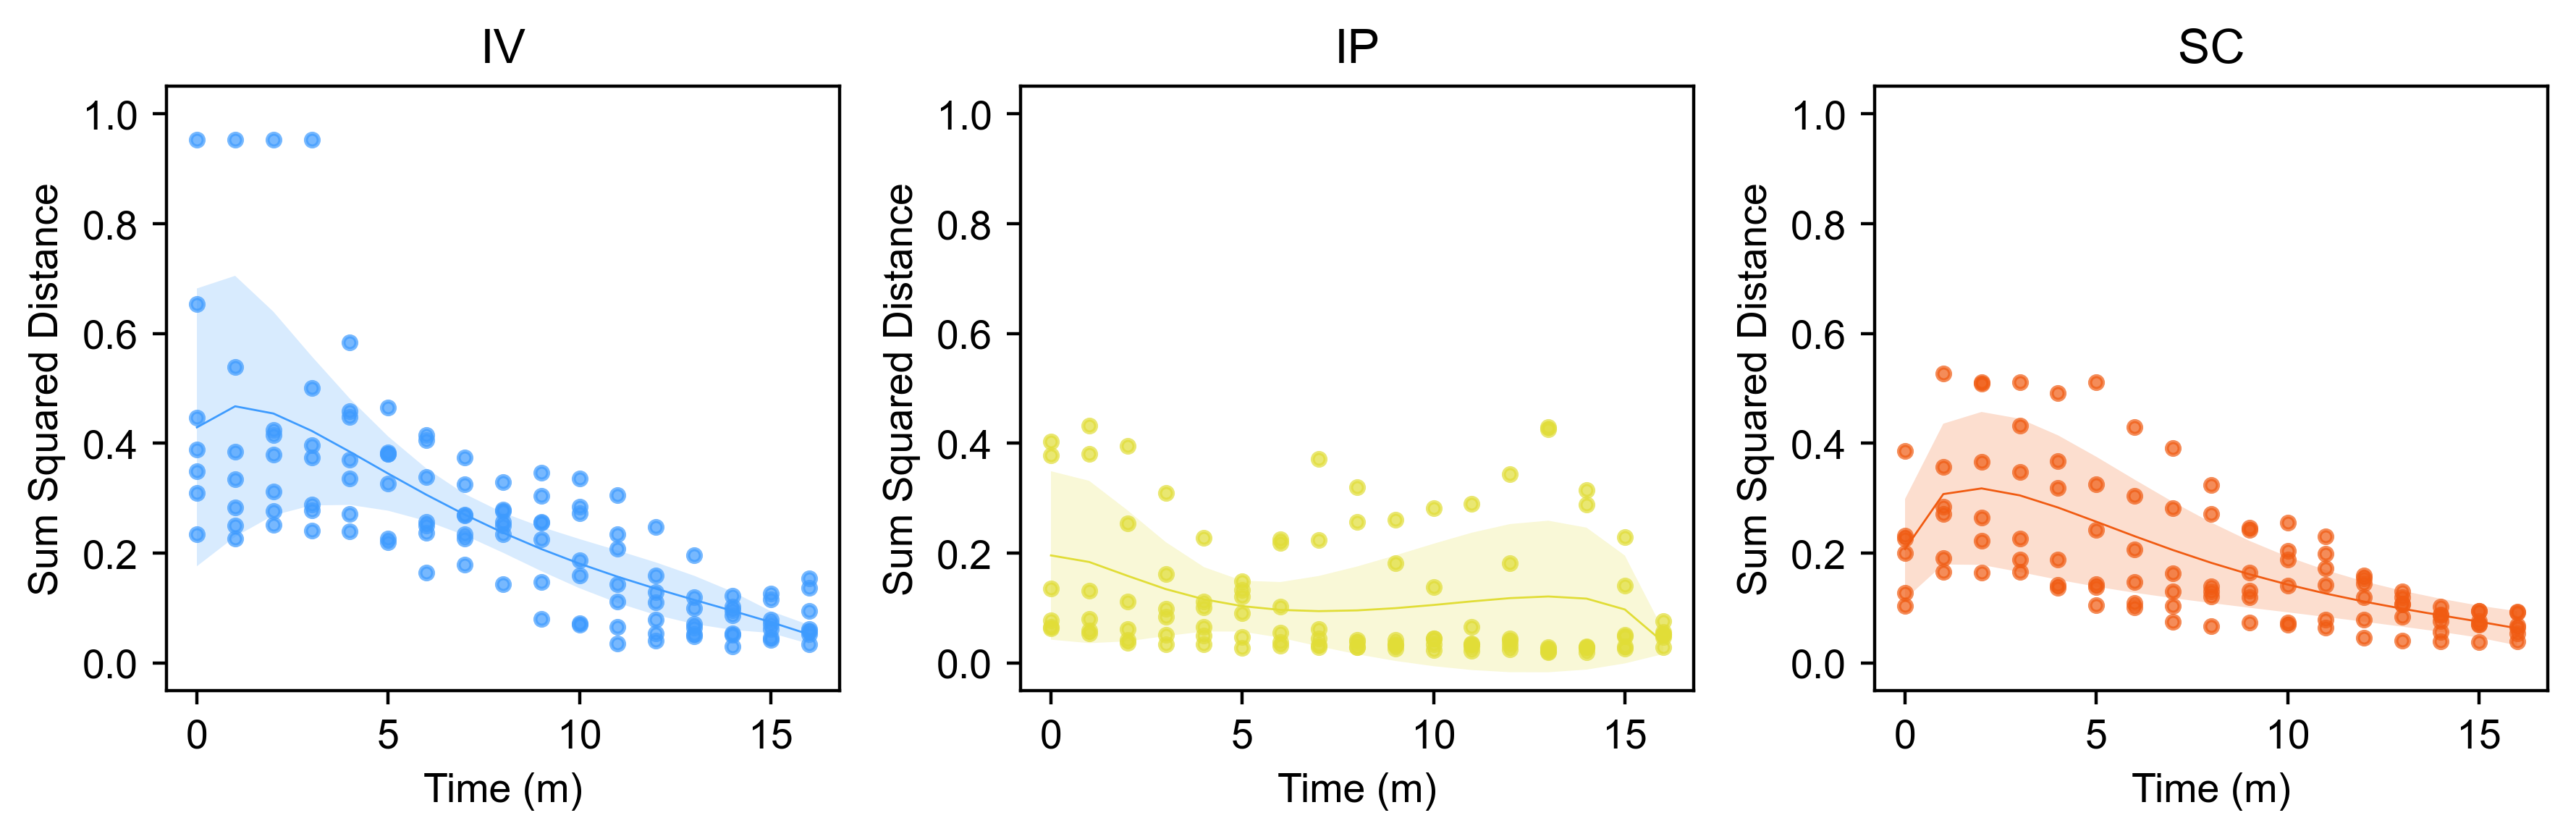

In [38]:
groups={"IV":"k10iv","IP":"k10ip","SC":"k10sc"}
cmap = plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

coeff_results = {}
#biexponential
def f(x, a,alpha,b,beta):
    return a*np.exp(-alpha*x)+b*np.exp(-beta*x)
    
def optimize_p0(f,x,y):
    a_values = np.linspace(0-2, 2, 5)
    b_values = np.linspace(0.01, 2, 10)
    c_values = np.linspace(0, 2, 5)
    d_values = np.linspace(0.01, 2, 10)
    
    best_p0 = None
    min_error = np.inf
    
    for a in a_values:
        for b in b_values:
            for c in c_values:
                for d in d_values:
                    p0 = [a, b, c, d]
                    try:
                        coeff, _ = scipy.optimize.curve_fit(f, x, y, p0=p0)
                        y_hat = np.array([f(x_i, *coeff) for x_i in x])
                        error = np.sum((y-y_hat)**2)
                        if error < min_error:
                            min_error = error
                            best_p0 = p0
                    except:
                        continue
    return best_p0

fig, ax = plt.subplots(1,3,figsize=(9,3),dpi=400)
for g, key in enumerate(groups.keys()):
    print(key)
    group=groups[key]
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*20,selected_subgroups=[group])
    block_labels_normal_unconv, block_labels_normal = module_usage_density(config, labels_df[group],0, 60, 20)
    block_labels_normal.shape
    
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=["saliv"])
    label_counts=module_usage_dist(config,labels_df)
    mean_label_counts=np.mean(label_counts,axis=0)
    
    mean_label_counts_block = np.expand_dims(mean_label_counts, axis=1)
    mean_label_counts_block = np.tile(mean_label_counts_block, (1, block_labels_normal.shape[2]))
    
    out=np.zeros_like(block_labels_normal)
    for sess in range(block_labels_normal.shape[0]):
        out[sess,:,:]=np.square(block_labels_normal[sess,:,:]-mean_label_counts_block)
    
    dist=np.sum(out,axis=1)
    xpts=np.arange(0,dist.shape[1],1)
    
    # mean = np.mean(dist,axis=0)
    # sem = np.std(dist,axis=0)/np.sqrt(dist.shape[0])
    y_all=[]
    coeff_all=[]
    for sess in range(dist.shape[0]):
        ax[g].scatter(xpts,dist[sess,:],label=group,color=colors[g],s=10,alpha=0.7)
        optimal_p0 = optimize_p0(f,xpts,dist[sess,:])
        coeff, _ = scipy.optimize.curve_fit(f,xpts,dist[sess,:],p0=optimal_p0)
        print(coeff)
        coeff_all.append(coeff)
        dist_fit=f(xpts,*coeff)
        y_all.append(dist_fit)
        #ax[g].plot(xpts,dist_fit)#,color=colors[g])
    coeff_results[key]=coeff_all
    mean = np.mean(np.array(y_all),axis=0)
    std = np.std(np.array(y_all),axis=0)
    ax[g].plot(xpts,mean,color=colors[g],linewidth=0.5)
    ax[g].fill_between(xpts,mean-std,mean+std,alpha=0.2,color=colors[g],edgecolor="none")
    dist_fit=f(xpts,*coeff)
    ax[g].set_title(key)
    ax[g].set_ylabel("Sum Squared Distance")
    ax[g].set_xlabel("Time (m)")
    ax[g].set_ylim([-.05,1.05])
plt.tight_layout()

if save==True:
    plt.savefig(save_path+"pk_fitting_behavior_ylim.png",dpi=500)

In [ ]:
groups={"IV":"k10iv","IP":"k10ip","SC":"k10sc"}
cmap = plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

coeff_results = {}
#biexponential
def f(x, a,alpha,b,beta):
    return a*np.exp(-alpha*x)+b*np.exp(-beta*x)
    
def optimize_p0(f,x,y):
    a_values = np.linspace(0-2, 2, 5)
    b_values = np.linspace(0.01, 2, 10)
    c_values = np.linspace(0, 2, 5)
    d_values = np.linspace(0.01, 2, 10)
    
    best_p0 = None
    min_error = np.inf
    
    for a in a_values:
        for b in b_values:
            for c in c_values:
                for d in d_values:
                    p0 = [a, b, c, d]
                    try:
                        coeff, _ = scipy.optimize.curve_fit(f, x, y, p0=p0)
                        y_hat = np.array([f(x_i, *coeff) for x_i in x])
                        error = np.sum((y-y_hat)**2)
                        if error < min_error:
                            min_error = error
                            best_p0 = p0
                    except:
                        continue
    return best_p0

fig, ax = plt.subplots(1,3,figsize=(9,3),dpi=400)
for g, key in enumerate(groups.keys()):
    print(key)
    group=groups[key]
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*20,selected_subgroups=[group])
    block_labels_normal_unconv, block_labels_normal = module_usage_density(config, labels_df[group],0, 60, 20)
    block_labels_normal.shape
    
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=["saliv"])
    label_counts=module_usage_dist(config,labels_df)
    mean_label_counts=np.mean(label_counts,axis=0)
    
    mean_label_counts_block = np.expand_dims(mean_label_counts, axis=1)
    mean_label_counts_block = np.tile(mean_label_counts_block, (1, block_labels_normal.shape[2]))
    
    out=np.zeros_like(block_labels_normal)
    for sess in range(block_labels_normal.shape[0]):
        out[sess,:,:]=np.square(block_labels_normal[sess,:,:]-mean_label_counts_block)
    
    dist=np.sum(out,axis=1)
    xpts=np.arange(0,dist.shape[1],1)
    
    # mean = np.mean(dist,axis=0)
    # sem = np.std(dist,axis=0)/np.sqrt(dist.shape[0])
    y_all=[]
    coeff_all=[]
    for sess in range(dist.shape[0]):
        ax[g].scatter(xpts,dist[sess,:],label=group,color=colors[g],s=10,alpha=0.7)
        optimal_p0 = optimize_p0(f,xpts,dist[sess,:])
        coeff, _ = scipy.optimize.curve_fit(f,xpts,dist[sess,:],p0=optimal_p0)
        print(coeff)
        coeff_all.append(coeff)
        dist_fit=f(xpts,*coeff)
        y_all.append(dist_fit)
        #ax[g].plot(xpts,dist_fit)#,color=colors[g])
    coeff_results[key]=coeff_all
    mean = np.mean(np.array(y_all),axis=0)
    std = np.std(np.array(y_all),axis=0)
    ax[g].plot(xpts,mean,color=colors[g],linewidth=0.5)
    ax[g].fill_between(xpts,mean-std,mean+std,alpha=0.2,color=colors[g],edgecolor="none")
    dist_fit=f(xpts,*coeff)
    ax[g].set_title(key)
    ax[g].set_ylabel("Sum Squared Distance")
    ax[g].set_xlabel("Time (m)")
    ax[g].set_ylim([-.05,1.05])
plt.tight_layout()

if save==True:
    plt.savefig(save_path+"pk_fitting_behavior_ylim.png",dpi=500)

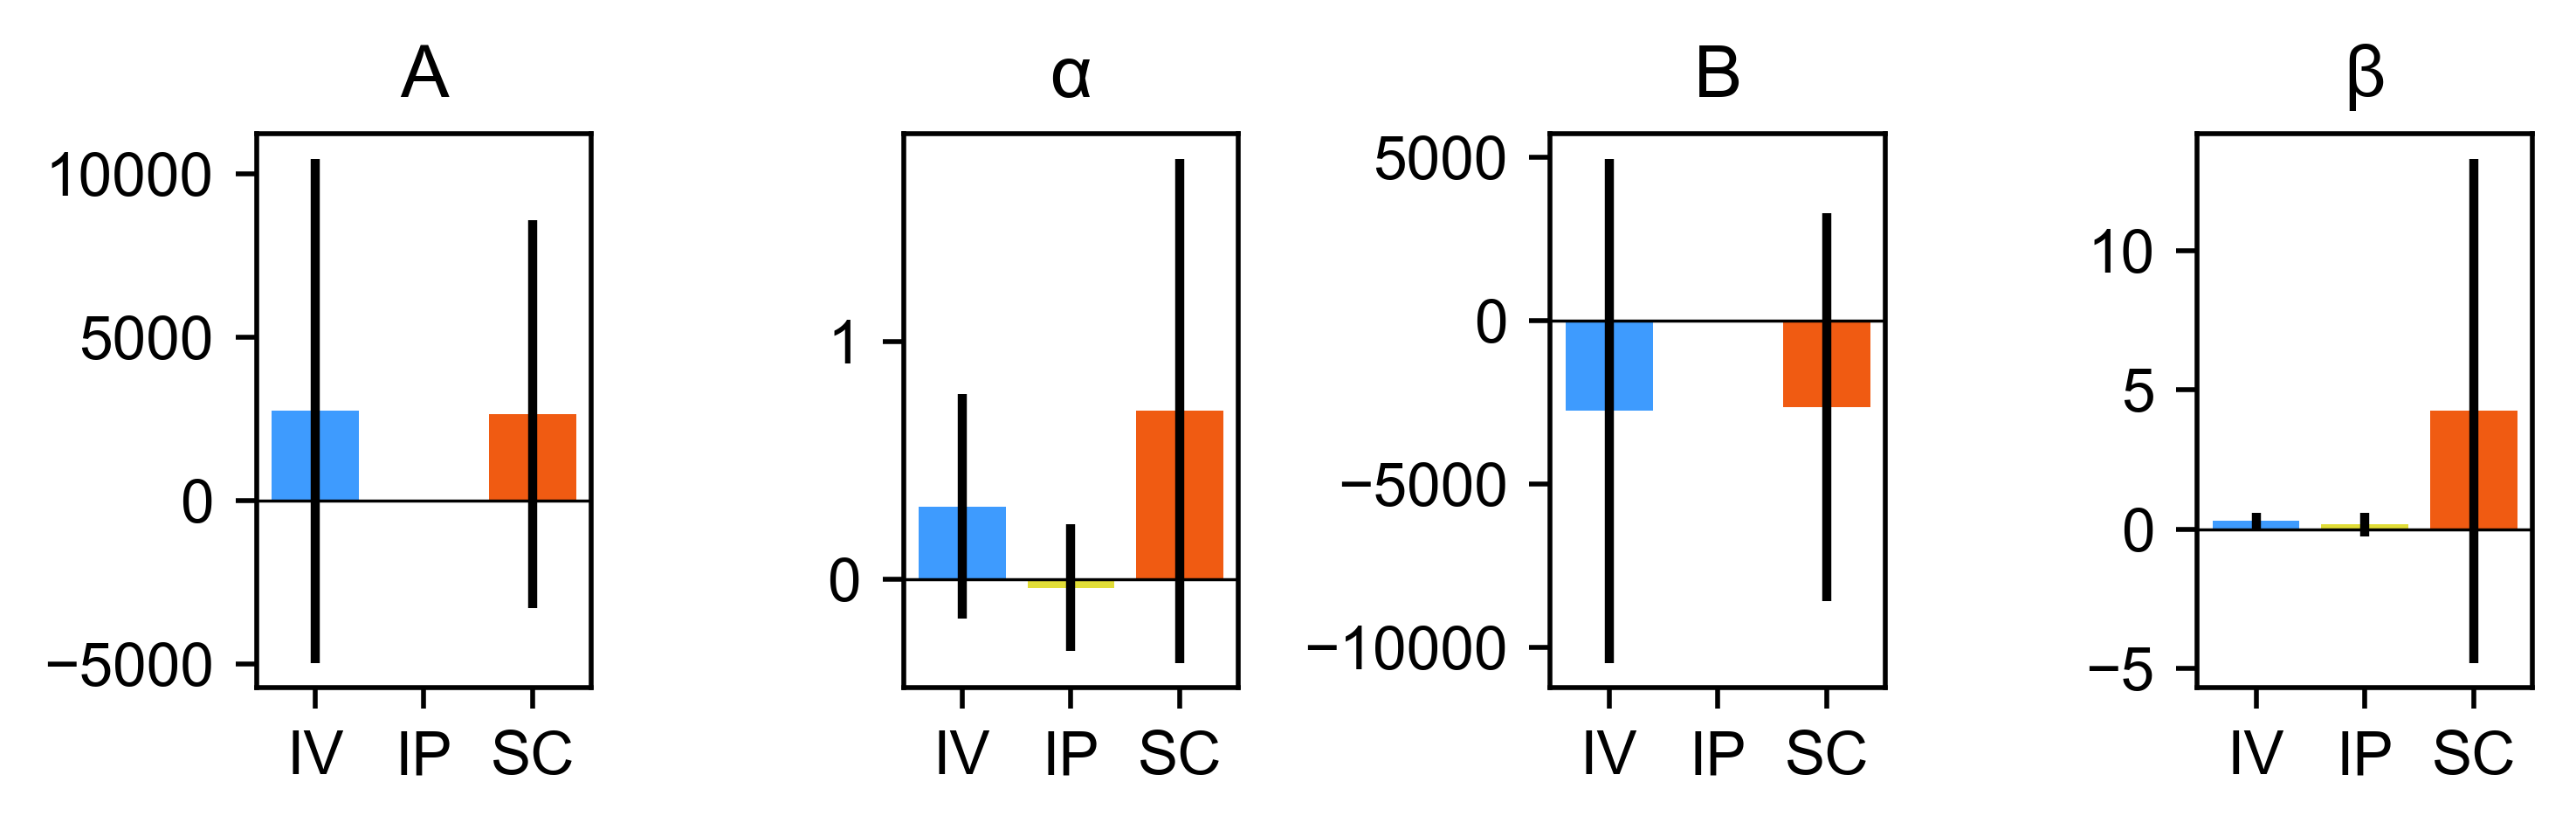

In [36]:
coeffs=4
fig, ax = plt.subplots(1,coeffs,figsize=(6,2),dpi=500)
ticks=[]
labels=[]
cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]
coeff_names=["Α","α","Β","β"]
for k, key in enumerate(coeff_results.keys()):
    array=np.array(coeff_results[key])
    mean=np.mean(array,axis=0)
    std=np.std(array,axis=0)
    ticks.append(k)
    labels.append(key)
    for coeff in range(coeffs):
        ax[coeff].bar(x=k,height=mean[coeff],color=colors[k])
        ax[coeff].errorbar(k,mean[coeff],yerr=std[coeff],color="black")

for coeff in range(coeffs):
    ax[coeff].set_xticks(ticks)
    ax[coeff].set_xticklabels(labels)
    ax[coeff].set_title(coeff_names[coeff])
    ax[coeff].axhline(0,color="black",linewidth=0.5)
    
plt.tight_layout()

if save==True:
    plt.savefig(save_path+"pk_fit_params_behavior.png",dpi=500)

In [67]:
loco_cv_df = pd.read_csv("/Users/snewbank/Behavior/B-SOID-Analysis/23-09-02-ketdr/locomotion/lda_and_cv/cv_accuracy_2components_withvame.csv",index_col=0)
loco_cv_df.columns=["30","60","150","300","600","1200"]
loco_cv_df

,30,60,150,300,600,1200
B-SOiD,0.307692,0.346154,0.384615,0.807692,0.461538,NaN
VAME,0.615385,0.615385,0.807692,0.730769,0.615385,NaN
Center,0.230769,0.269231,0.307692,0.269231,0.307692,NaN
Loco,0.576923,0.461538,0.615385,0.615385,0.576923,NaN
Center+Loco,0.576923,0.615385,0.576923,0.692308,0.730769,NaN
B-SOiD+Center+Loco,0.384615,0.461538,0.576923,0.769231,0.846154,NaN


Text(0, 0.5, 'Linear Discriminant Analysis\nLOOCV Accuracy')

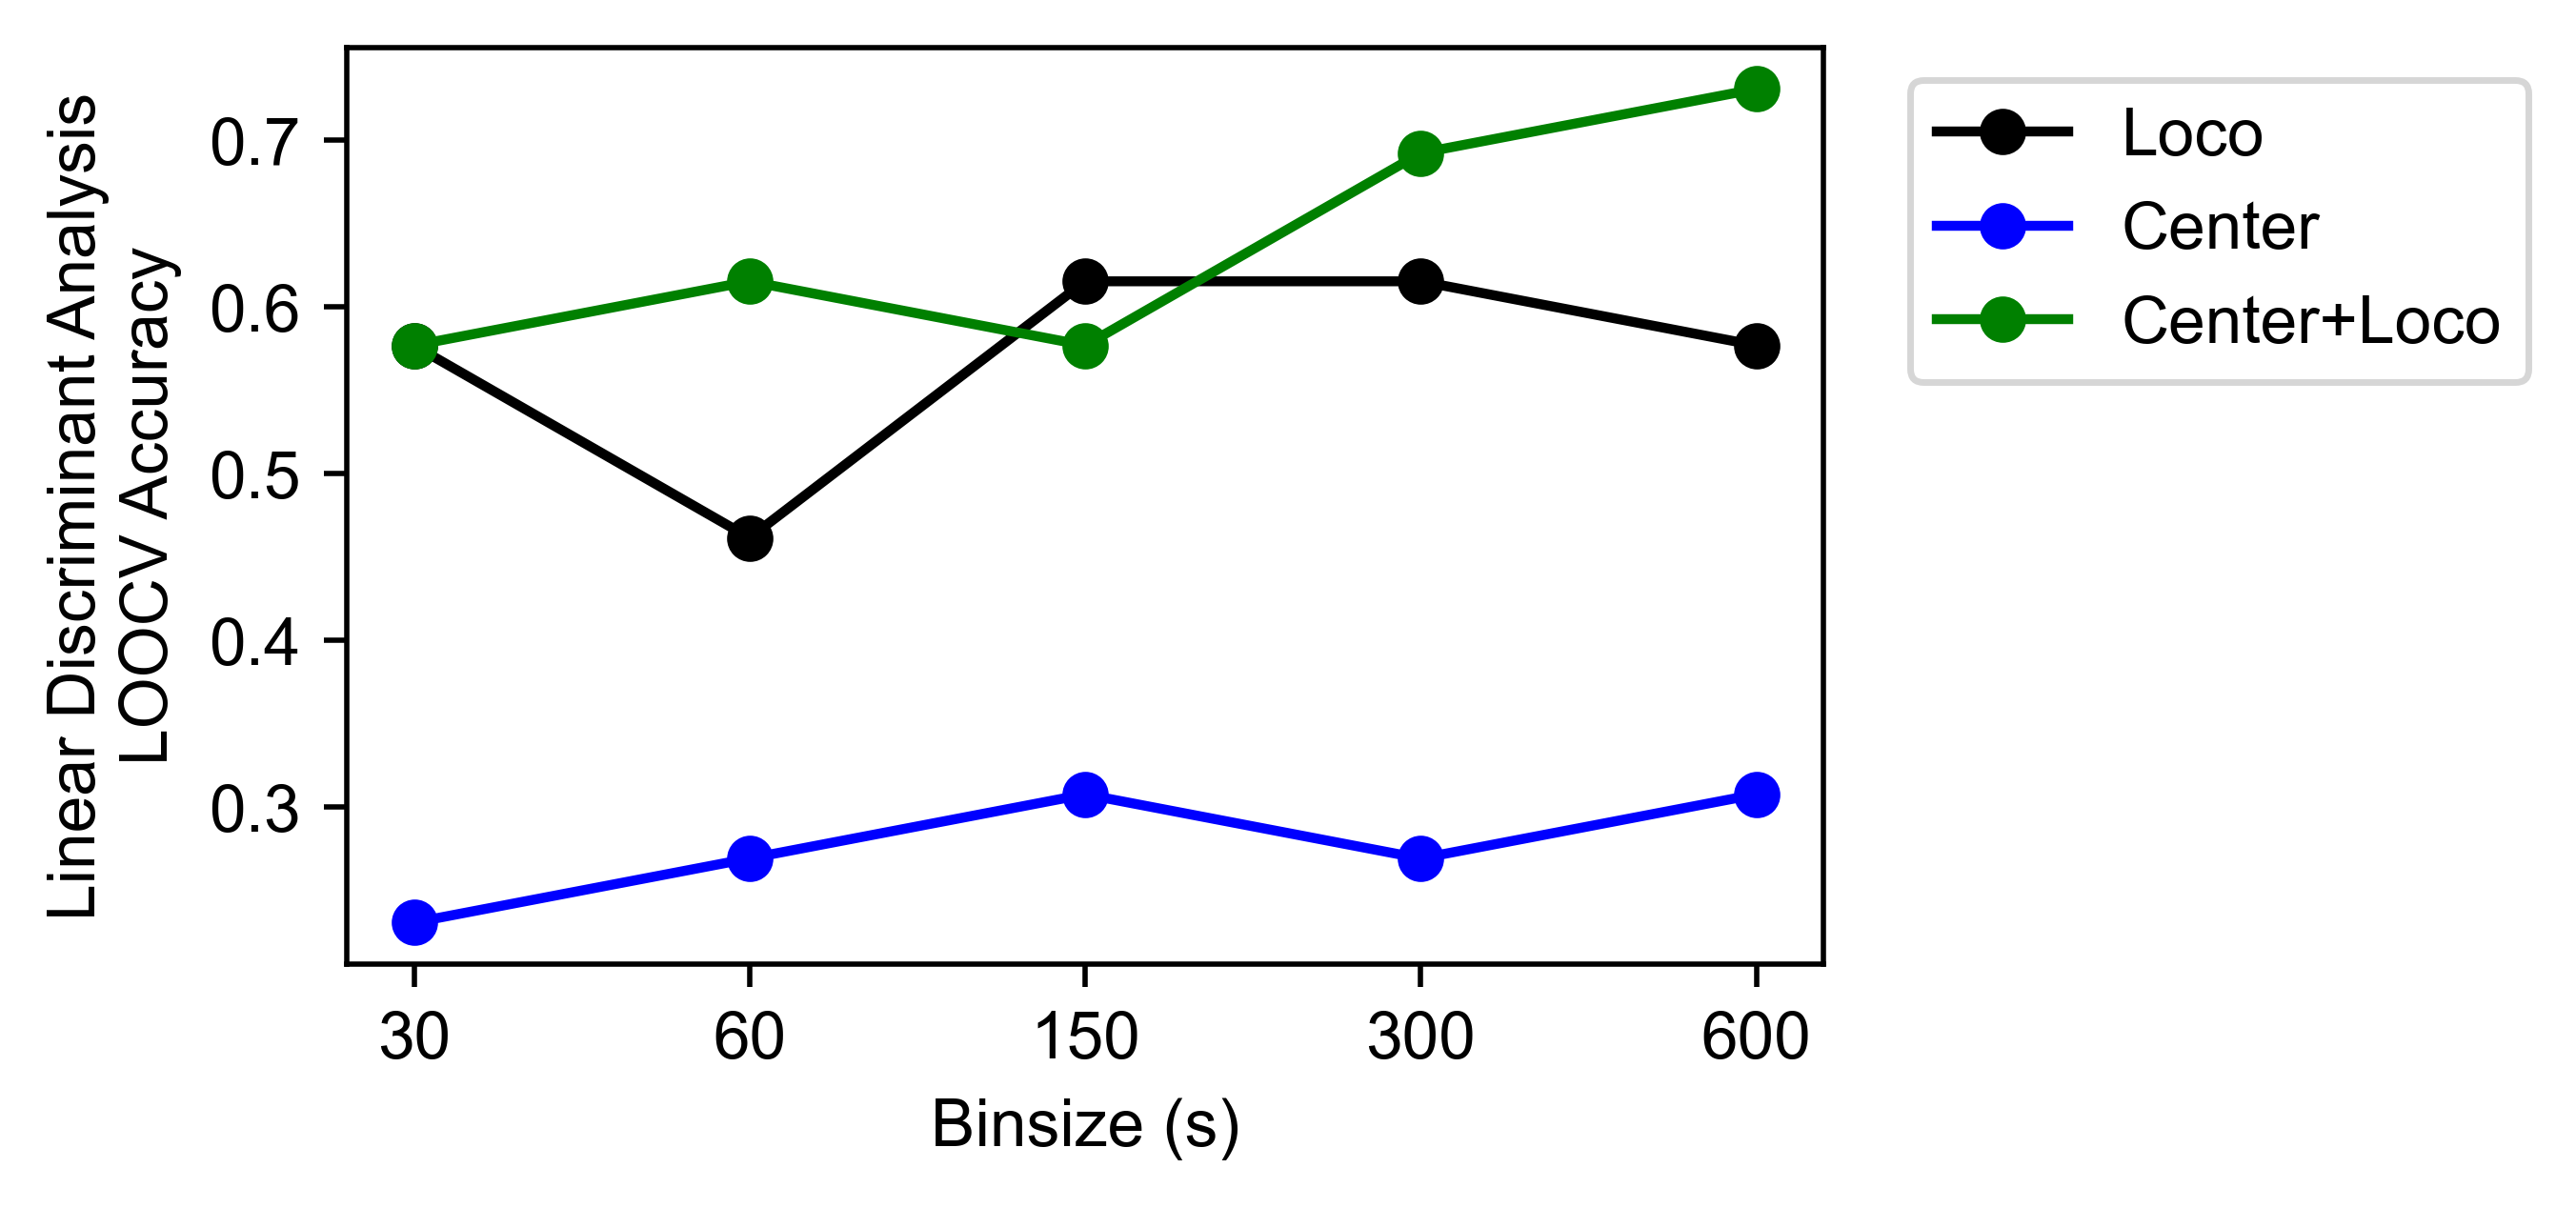

In [75]:
plt.figure(figsize=(4,2.5),dpi=500)
plt.plot(loco_cv_df.loc["Loco"],marker="o",label="Loco",color="black")
plt.plot(loco_cv_df.loc["Center"],marker="o",label="Center",color="blue")
plt.plot(loco_cv_df.loc["Center+Loco"],marker="o",label="Center+Loco",color="green")
plt.xlabel("Binsize (s)")
plt.legend(loc="upper right",bbox_to_anchor=(1.5,1))
plt.ylabel("Linear Discriminant Analysis\nLOOCV Accuracy")